# Uncovering Global Health Archetypes Using PCA and K-Means Clustering
**Course:** Data Exploration and Visualization
**Datasets:** WHO Life Expectancy (2000–2015) + World Bank Socioeconomic (2001–2019)
**Unit of Analysis:** Country averages across 2001–2015

## Step 1 — Import Libraries

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Output folders
IMAGE_DIR = "report_images"
TABLE_DIR = "report_tables"
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# Plot style — academic, no emoji
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight",
                     "savefig.facecolor": "white"})

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Libraries imported successfully.")


Libraries imported successfully.


---
## Step 2 — Load Datasets

Place both CSV files in the same folder as this notebook:
- `Life_Expectancy_Data.csv` — WHO dataset
- `life_expectancy.csv` — World Bank dataset


In [2]:
who = pd.read_csv("Life_Expectancy_Data.csv")
wb  = pd.read_csv("life_expectancy.csv")

# Strip whitespace from column names
who.columns = who.columns.str.strip()
wb.columns  = wb.columns.str.strip()

print("WHO  shape:", who.shape)
print("WHO  columns:", list(who.columns))
print()
print("WB   shape:", wb.shape)
print("WB   columns:", list(wb.columns))


WHO  shape: (2938, 22)
WHO  columns: ['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']

WB   shape: (3306, 16)
WB   columns: ['Country Name', 'Country Code', 'Region', 'IncomeGroup', 'Year', 'Life Expectancy World Bank', 'Prevelance of Undernourishment', 'CO2', 'Health Expenditure %', 'Education Expenditure %', 'Unemployment', 'Corruption', 'Sanitation', 'Injuries', 'Communicable', 'NonCommunicable']


In [36]:
import pandas as pd
who = pd.read_csv('Life_Expectancy_Data.csv')
who.columns = who.columns.str.strip()

print(f"WHO full dataset: {len(who)} rows")
print(f"Years available: {who['Year'].min()} - {who['Year'].max()}")

who_filtered = who[who['Year'].between(2001, 2015)]
print(f"WHO after filtering 2001-2015: {len(who_filtered)} rows")
print(f"Countries: {who_filtered['Country'].nunique()}")

WHO full dataset: 2938 rows
Years available: 2000 - 2015
WHO after filtering 2001-2015: 2755 rows
Countries: 193


---
## Step 3 — Merge Pipeline

Following the proposal methodology:
1. Filter to overlapping years **2001–2015**
2. Harmonise country names
3. Compute **country averages** (one row per country)
4. **Inner join** between WHO and World Bank


In [37]:
# 3a. Filter to 2001-2015
who_f = who[who['Year'].between(2001, 2015)].copy()
wb_f  = wb[wb['Year'].between(2001, 2015)].copy()

print("WHO  after year filter:", who_f.shape)
print("WB   after year filter:", wb_f.shape)


WHO  after year filter: (2755, 22)
WB   after year filter: (2610, 16)


In [38]:
# 3b. Harmonise country names
rename_who = {
    "United States of America"                            : "United States",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Democratic Republic of the Congo"                    : "Congo, Dem. Rep.",
    "Congo"                                               : "Congo, Rep.",
    "Bolivia (Plurinational State of)"                    : "Bolivia",
    "Venezuela (Bolivarian Republic of)"                  : "Venezuela, RB",
    "Iran (Islamic Republic of)"                          : "Iran, Islamic Rep.",
    "Republic of Korea"                                   : "Korea, Rep.",
    "Viet Nam"                                            : "Vietnam",
    "Czech Republic"                                      : "Czechia",
    "Kyrgyzstan"                                          : "Kyrgyz Republic",
    "Slovakia"                                            : "Slovak Republic",
    "Egypt"                                               : "Egypt, Arab Rep.",
    "Yemen"                                               : "Yemen, Rep.",
    "Gambia"                                              : "Gambia, The",
    "Côte d'Ivoire"                                       : "Cote d'Ivoire",
    "Syrian Arab Republic"                                : "Syrian Arab Republic",
    "Tanzania"                                            : "Tanzania",
    "Lao People's Democratic Republic"                    : "Lao PDR",
}
who_f['Country'] = who_f['Country'].replace(rename_who)
print("Country names harmonised.")


Country names harmonised.


In [39]:
# 3c. Country averages across 2001-2015
who_avg = who_f.groupby('Country').mean(numeric_only=True).reset_index()

# World Bank: country-specific median imputation BEFORE averaging
wb_num_cols = wb_f.select_dtypes(include=[np.number]).columns.tolist()
wb_num_cols = [c for c in wb_num_cols if c != 'Year']

wb_f_imp = wb_f.copy()
for col in wb_num_cols:
    wb_f_imp[col] = wb_f_imp.groupby('Country Name')[col].transform(
        lambda s: s.fillna(s.median())
    )
    wb_f_imp[col] = wb_f_imp[col].fillna(wb_f_imp[col].median())

wb_avg = wb_f_imp.groupby('Country Name').mean(numeric_only=True).reset_index()

# Preserve Region and IncomeGroup
wb_meta = wb_f.groupby('Country Name')[['Region','IncomeGroup']].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
).reset_index()
wb_avg = wb_avg.merge(wb_meta, on='Country Name', how='left')

print("WHO  country averages:", who_avg.shape)
print("WB   country averages:", wb_avg.shape)


WHO  country averages: (193, 21)
WB   country averages: (174, 15)


In [40]:
# 3d. Inner join
df = pd.merge(
    who_avg,
    wb_avg,
    left_on='Country',
    right_on='Country Name',
    how='inner'
).drop(columns=['Country Name', 'Year_x', 'Year_y'], errors='ignore')

print("Merged dataset shape:", df.shape)
print("Countries retained  :", df['Country'].nunique())
display(df[['Country','Region','IncomeGroup']].head(10))


Merged dataset shape: (163, 33)
Countries retained  : 163


,Country,Region,IncomeGroup
0,Afghanistan,South Asia,Low income
1,Albania,Europe & Central Asia,Upper middle income
2,Algeria,Middle East & North Africa,Lower middle income
3,Angola,Sub-Saharan Africa,Lower middle income
4,Antigua and Barbuda,Latin America & Caribbean,High income
5,Argentina,Latin America & Caribbean,Upper middle income
6,Armenia,Europe & Central Asia,Upper middle income
7,Australia,East Asia & Pacific,High income
8,Austria,Europe & Central Asia,High income
9,Azerbaijan,Europe & Central Asia,Upper middle income


In [41]:
# Verify regional means from merged dataset
# After country averages are computed
region_means = df.groupby('Region')['Life expectancy'].mean().round(1)
print("Mean Life Expectancy by Region:")
print(region_means.sort_values(ascending=False).to_string())

Mean Life Expectancy by Region:
Region
North America                 80.0
Europe & Central Asia         76.7
Middle East & North Africa    74.0
Latin America & Caribbean     73.1
East Asia & Pacific           71.8
South Asia                    67.6
Sub-Saharan Africa            57.1


In [42]:
income_medians = df.groupby('IncomeGroup')['Life expectancy'].median().round(1)
print("Median Life Expectancy by Income Group:")
print(income_medians.to_string())

Median Life Expectancy by Income Group:
IncomeGroup
High income            80.1
Low income             56.0
Lower middle income    66.1
Upper middle income    73.0


---
## Step 4 — Feature Selection


In [7]:
# Final feature set — carefully selected based on proposal and literature
FEATURES = [
    # WHO variables
    'Life expectancy',          # Target variable
    'GDP',                      # Economic development
    'Schooling',                # Education
    'Total expenditure',        # Health expenditure (% GDP)
    'Adult Mortality',          # Health outcome
    'HIV/AIDS',                 # Epidemic burden
    'Alcohol',                  # Lifestyle
    'Hepatitis B',              # Immunisation
    'Polio',                    # Immunisation
    'Diphtheria',               # Immunisation
    'BMI',                      # Nutrition/lifestyle
    # World Bank variables
    'Health Expenditure %',     # WB health spending
    'Education Expenditure %',  # WB education spending
    'Sanitation',               # Infrastructure
    'Undernourishment',         # Nutrition deprivation
    'CO2',                      # Development proxy
    'Communicable',             # Disease burden
    'NonCommunicable',          # Disease burden
]

# Map WB column name
if 'Prevelance of Undernourishment' in df.columns:
    df = df.rename(columns={'Prevelance of Undernourishment': 'Undernourishment'})

available = [f for f in FEATURES if f in df.columns]
print(f"Features available: {len(available)}/{len(FEATURES)}")
print(available)


Features available: 18/18
['Life expectancy', 'GDP', 'Schooling', 'Total expenditure', 'Adult Mortality', 'HIV/AIDS', 'Alcohol', 'Hepatitis B', 'Polio', 'Diphtheria', 'BMI', 'Health Expenditure %', 'Education Expenditure %', 'Sanitation', 'Undernourishment', 'CO2', 'Communicable', 'NonCommunicable']


---
## Step 5 — Missing Values


In [8]:
# Missing values BEFORE imputation
missing = df[available].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Missing Values Summary (before imputation):")
display(missing_df)
print(f"Total missing cells: {df[available].isnull().sum().sum()}")

missing_df.to_csv(os.path.join(TABLE_DIR, "missing_values.csv"))


Missing Values Summary (before imputation):


,Missing Count,Missing %
Hepatitis B,9,5.5
Life expectancy,7,4.3
GDP,7,4.3
Adult Mortality,7,4.3
Schooling,5,3.1
BMI,4,2.5
Alcohol,2,1.2
Total expenditure,1,0.6


Total missing cells: 42


In [9]:
# Imputation: country-specific median first, then global median
for col in available:
    # Try country-specific median
    df[col] = df.groupby('Country')[col].transform(
        lambda s: s.fillna(s.median())
    ) if 'Country' in df.columns else df[col]
    # Fill any remaining with global median
    df[col] = df[col].fillna(df[col].median())

print(f"Missing values after imputation: {df[available].isnull().sum().sum()}")


Missing values after imputation: 0


---
## Step 6 — Descriptive Statistics


In [10]:
summary = df[available].describe().T
summary['Skewness'] = df[available].skew()
summary['Kurtosis'] = df[available].kurtosis()

display(summary[['mean','std','min','25%','50%','75%','max','Skewness','Kurtosis']].round(2))
summary.to_csv(os.path.join(TABLE_DIR, "descriptive_statistics.csv"))


,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis
Life expectancy,69.61,9.25,46.59,62.95,72.66,75.55,8.271000e+01,-0.62,-0.54
GDP,7300.62,10831.10,136.18,844.10,3045.05,7642.98,5.866618e+04,2.34,5.55
Schooling,12.01,3.43,0.00,10.06,12.41,14.19,2.001000e+01,-0.72,1.21
Total expenditure,6.13,2.26,2.02,4.66,6.01,7.20,1.724000e+01,1.76,6.87
Adult Mortality,161.77,96.90,12.53,75.83,141.23,216.13,5.505300e+02,1.23,1.57
HIV/AIDS,1.60,3.82,0.10,0.10,0.10,0.94,2.251000e+01,3.61,13.88
Alcohol,4.46,3.82,0.01,1.00,3.76,7.55,1.353000e+01,0.58,-0.84
Hepatitis B,78.22,18.90,8.00,67.68,83.21,93.70,9.900000e+01,-1.43,2.36
Polio,82.16,16.88,9.00,73.50,87.80,95.87,9.900000e+01,-1.37,2.05
Diphtheria,82.57,17.36,9.00,72.93,89.00,95.73,9.900000e+01,-1.52,2.44


---
## Step 7 — EDA: Life Expectancy Distribution


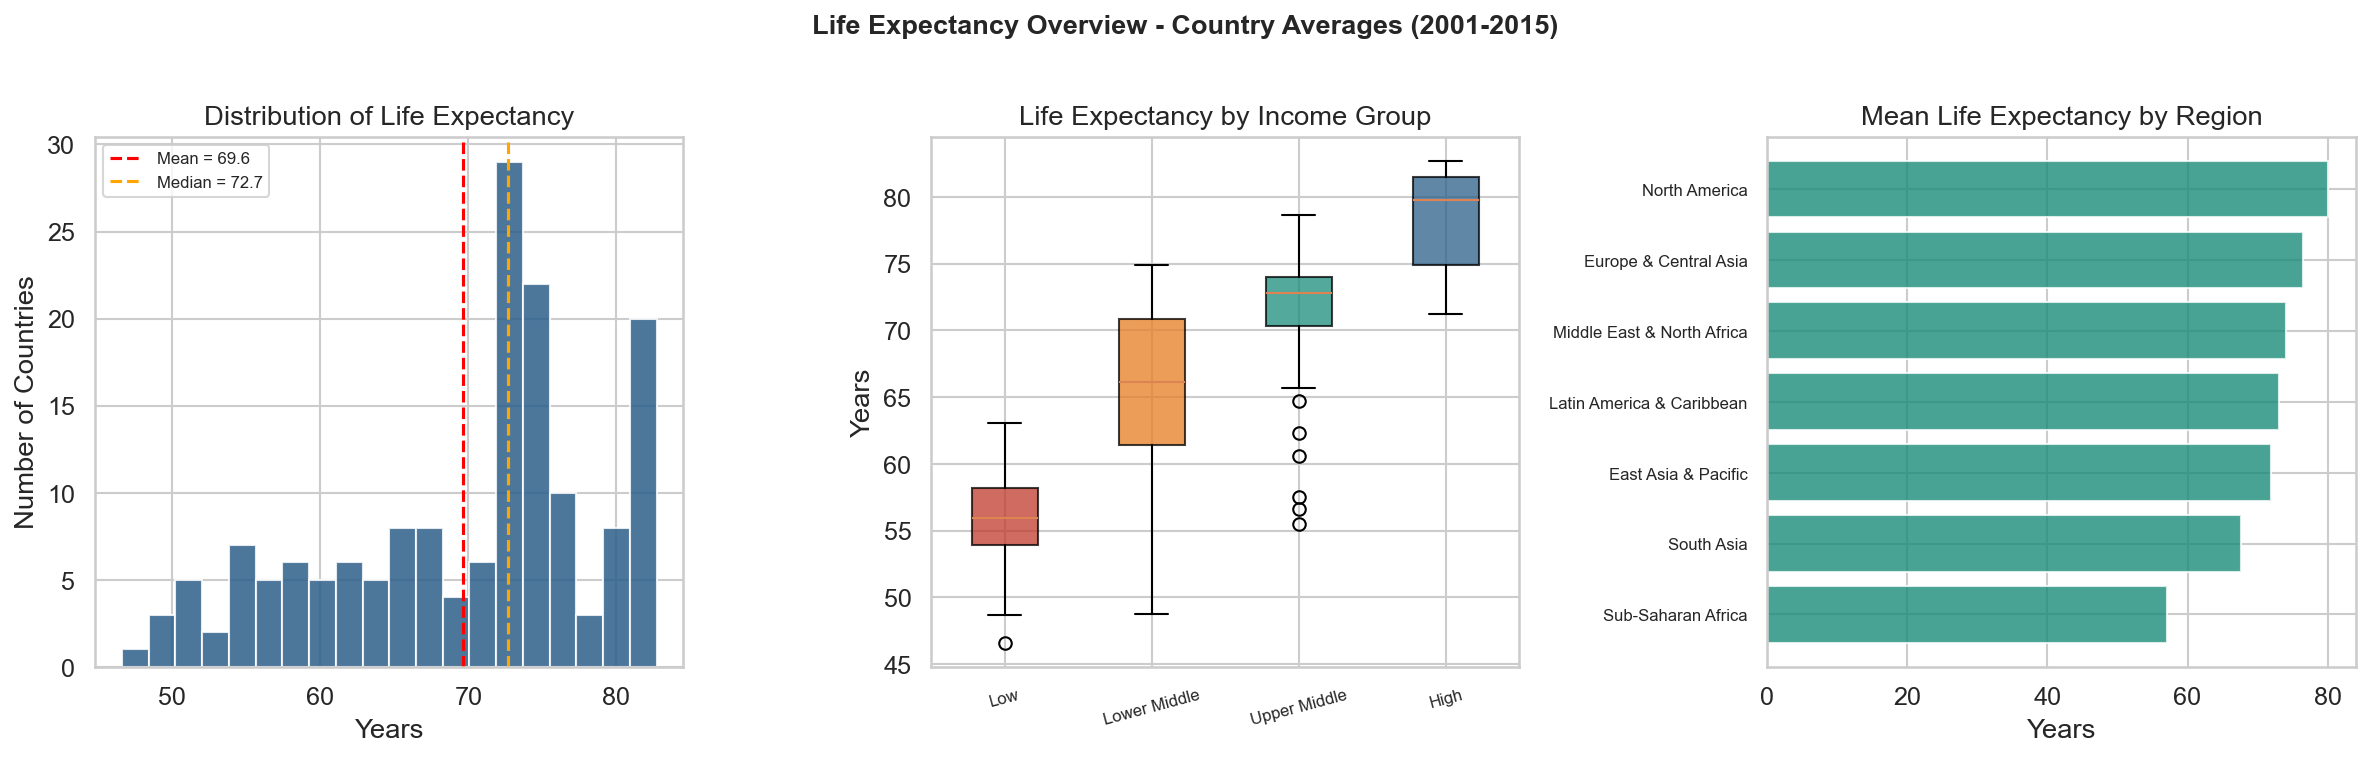

Figure saved.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(df['Life expectancy'], bins=20, color='#2C5F8A', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Life expectancy'].mean(), color='red', linestyle='--',
                label=f"Mean = {df['Life expectancy'].mean():.1f}")
axes[0].axvline(df['Life expectancy'].median(), color='orange', linestyle='--',
                label=f"Median = {df['Life expectancy'].median():.1f}")
axes[0].set_title("Distribution of Life Expectancy")
axes[0].set_xlabel("Years")
axes[0].set_ylabel("Number of Countries")
axes[0].legend(fontsize=8)

# Boxplot by Income Group
income_order = ['Low income','Lower middle income','Upper middle income','High income']
income_data  = [df[df['IncomeGroup']==ig]['Life expectancy'].dropna() for ig in income_order]
bp = axes[1].boxplot(income_data, patch_artist=True)
colors_bp = ['#C0392B','#E67E22','#1A8C7A','#2C5F8A']
for patch, c in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[1].set_xticklabels(['Low', 'Lower Middle', 'Upper Middle', 'High'], fontsize=8, rotation=15)
axes[1].set_title("Life Expectancy by Income Group")
axes[1].set_ylabel("Years")

# Mean by Region
reg_mean = df.groupby('Region')['Life expectancy'].mean().sort_values()
axes[2].barh(range(len(reg_mean)), reg_mean.values, color='#1A8C7A', alpha=0.8)
axes[2].set_yticks(range(len(reg_mean)))
axes[2].set_yticklabels(reg_mean.index, fontsize=8)
axes[2].set_title("Mean Life Expectancy by Region")
axes[2].set_xlabel("Years")

plt.suptitle("Life Expectancy Overview - Country Averages (2001-2015)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig1_life_expectancy_overview.png"), dpi=150)
plt.show()
print("Figure saved.")


---
## Step 8 — EDA: Univariate Distributions


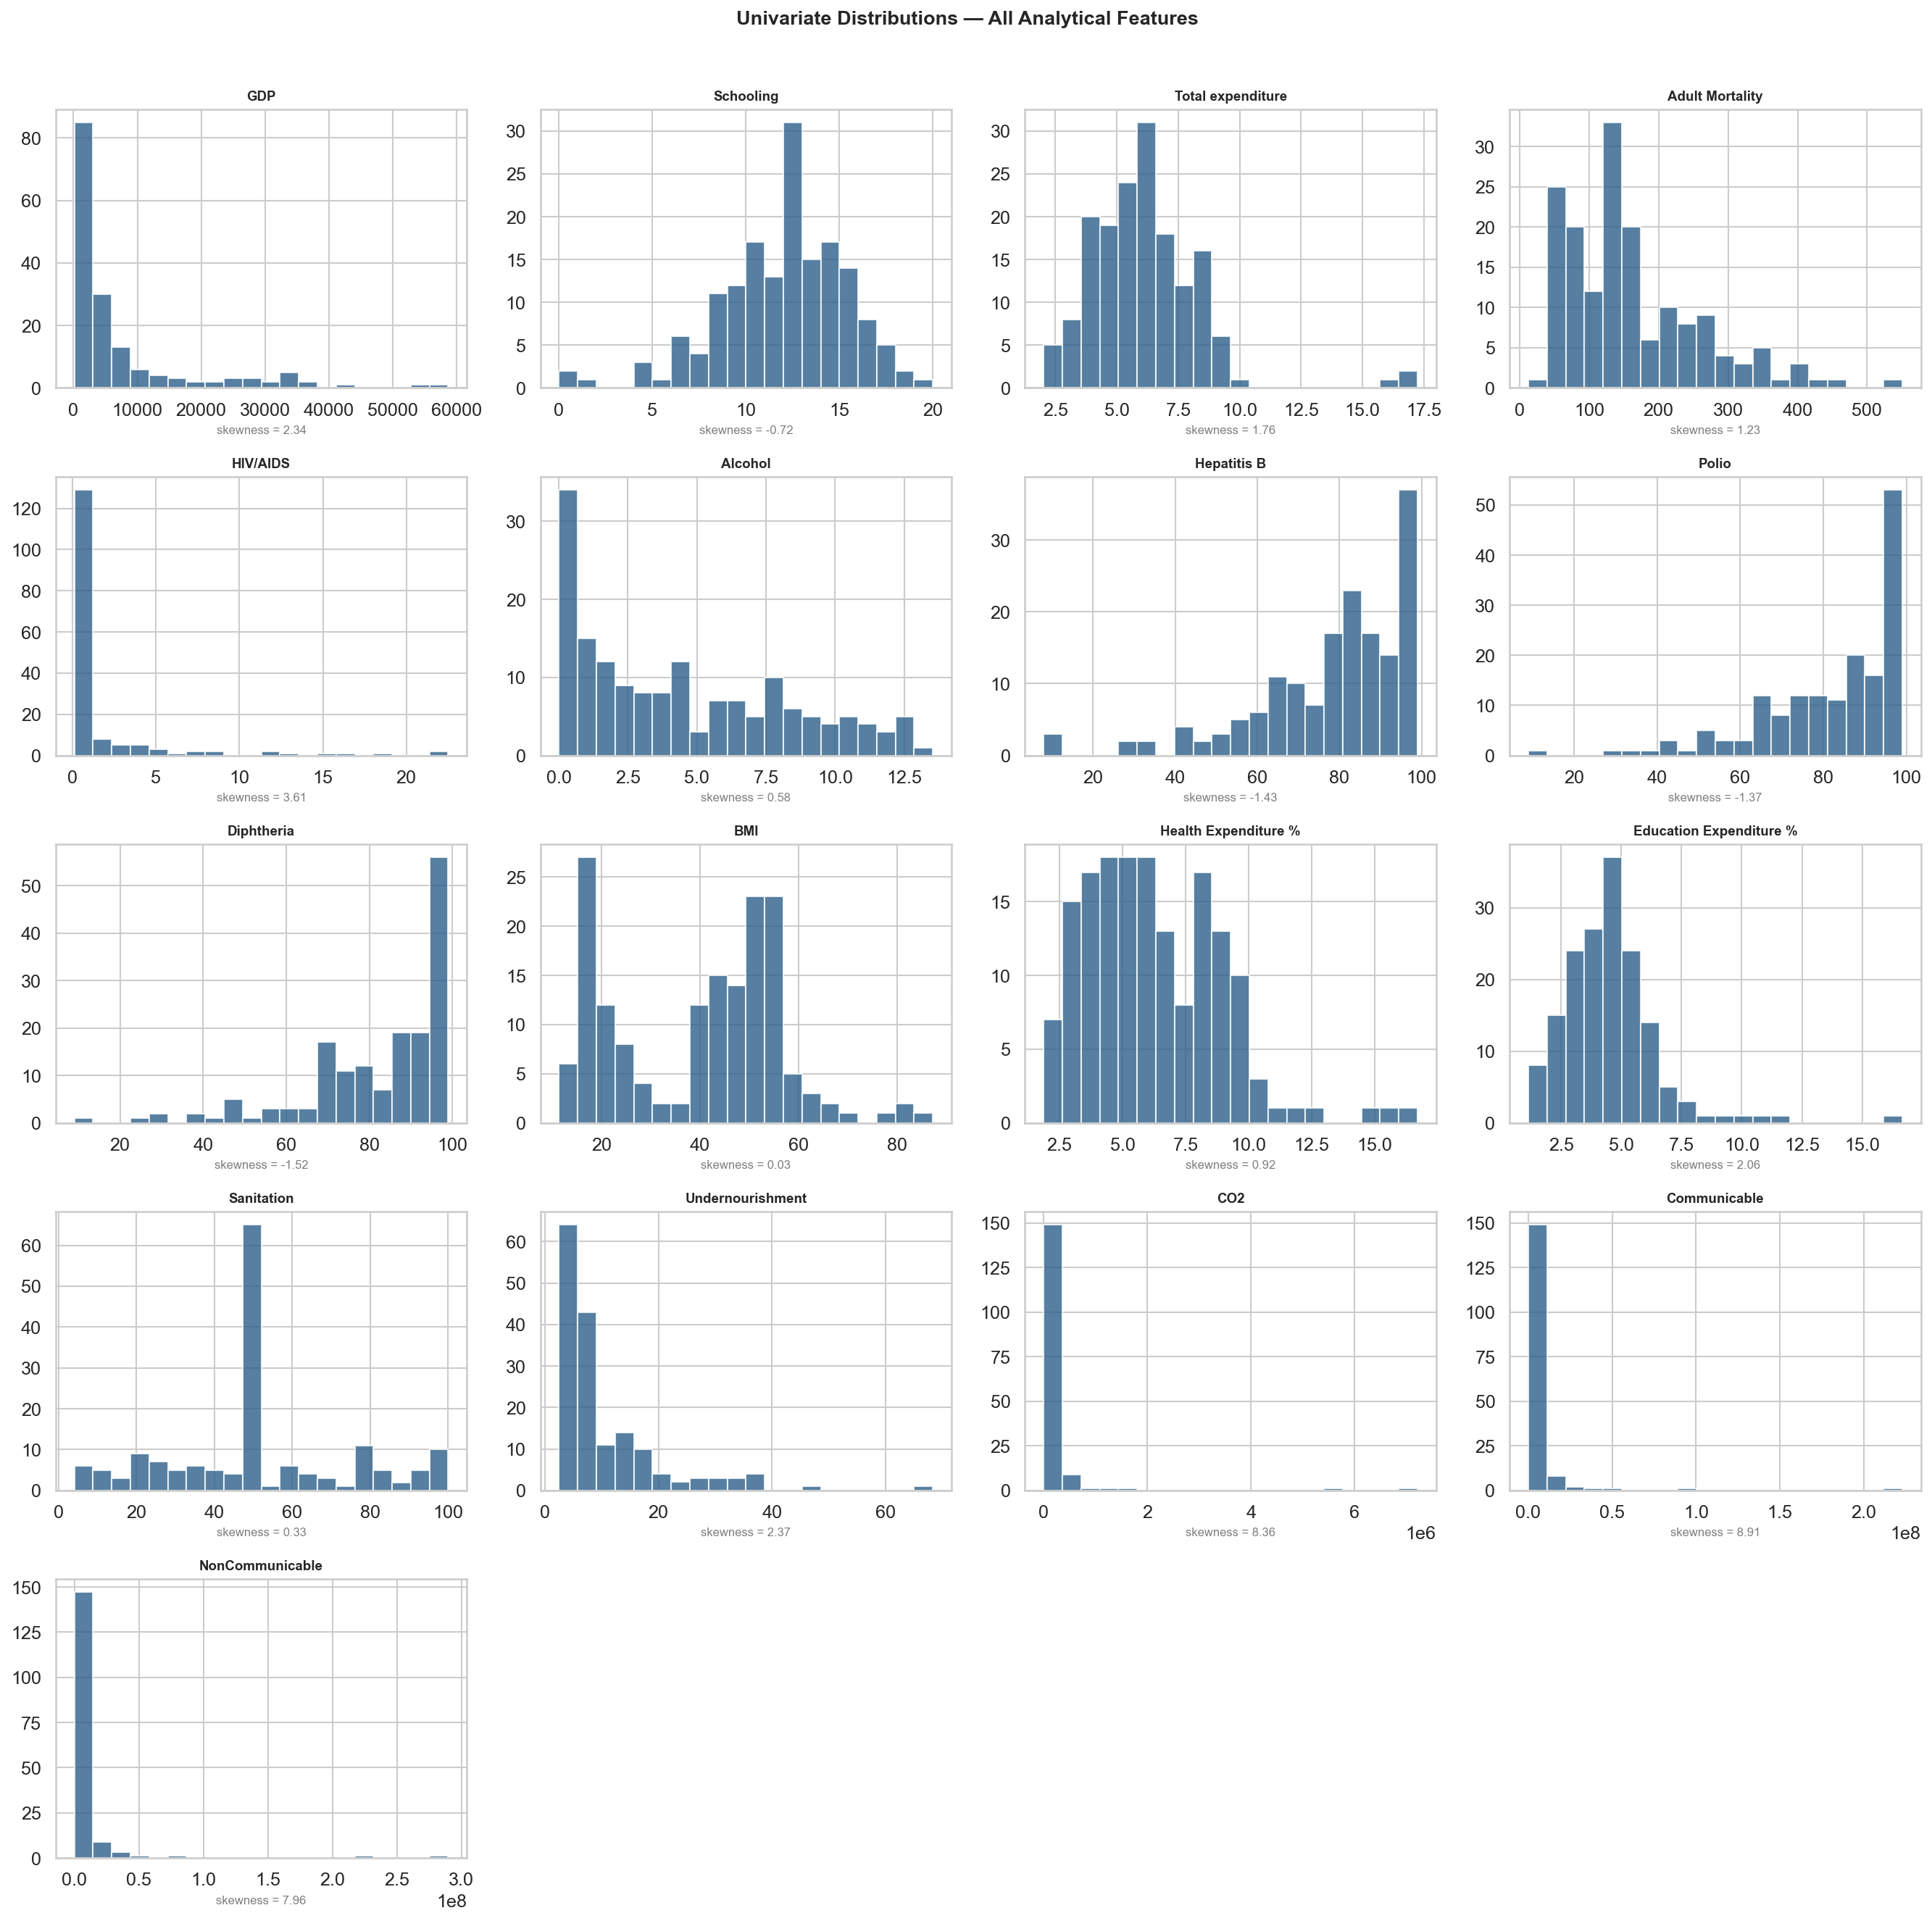

Figure saved.


In [12]:
plot_vars = [f for f in available if f != 'Life expectancy']
n = len(plot_vars)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3.5))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    axes[i].hist(df[var].dropna(), bins=20, color='#2C5F8A', edgecolor='white', alpha=0.8)
    skew_val = df[var].skew()
    axes[i].set_title(var, fontsize=9, fontweight='bold')
    axes[i].set_xlabel(f"skewness = {skew_val:.2f}", fontsize=8, color='gray')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Univariate Distributions — All Analytical Features",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig2_univariate_distributions.png"), dpi=150)
plt.show()
print("Figure saved.")


---
## Step 9 — EDA: Correlation Matrix


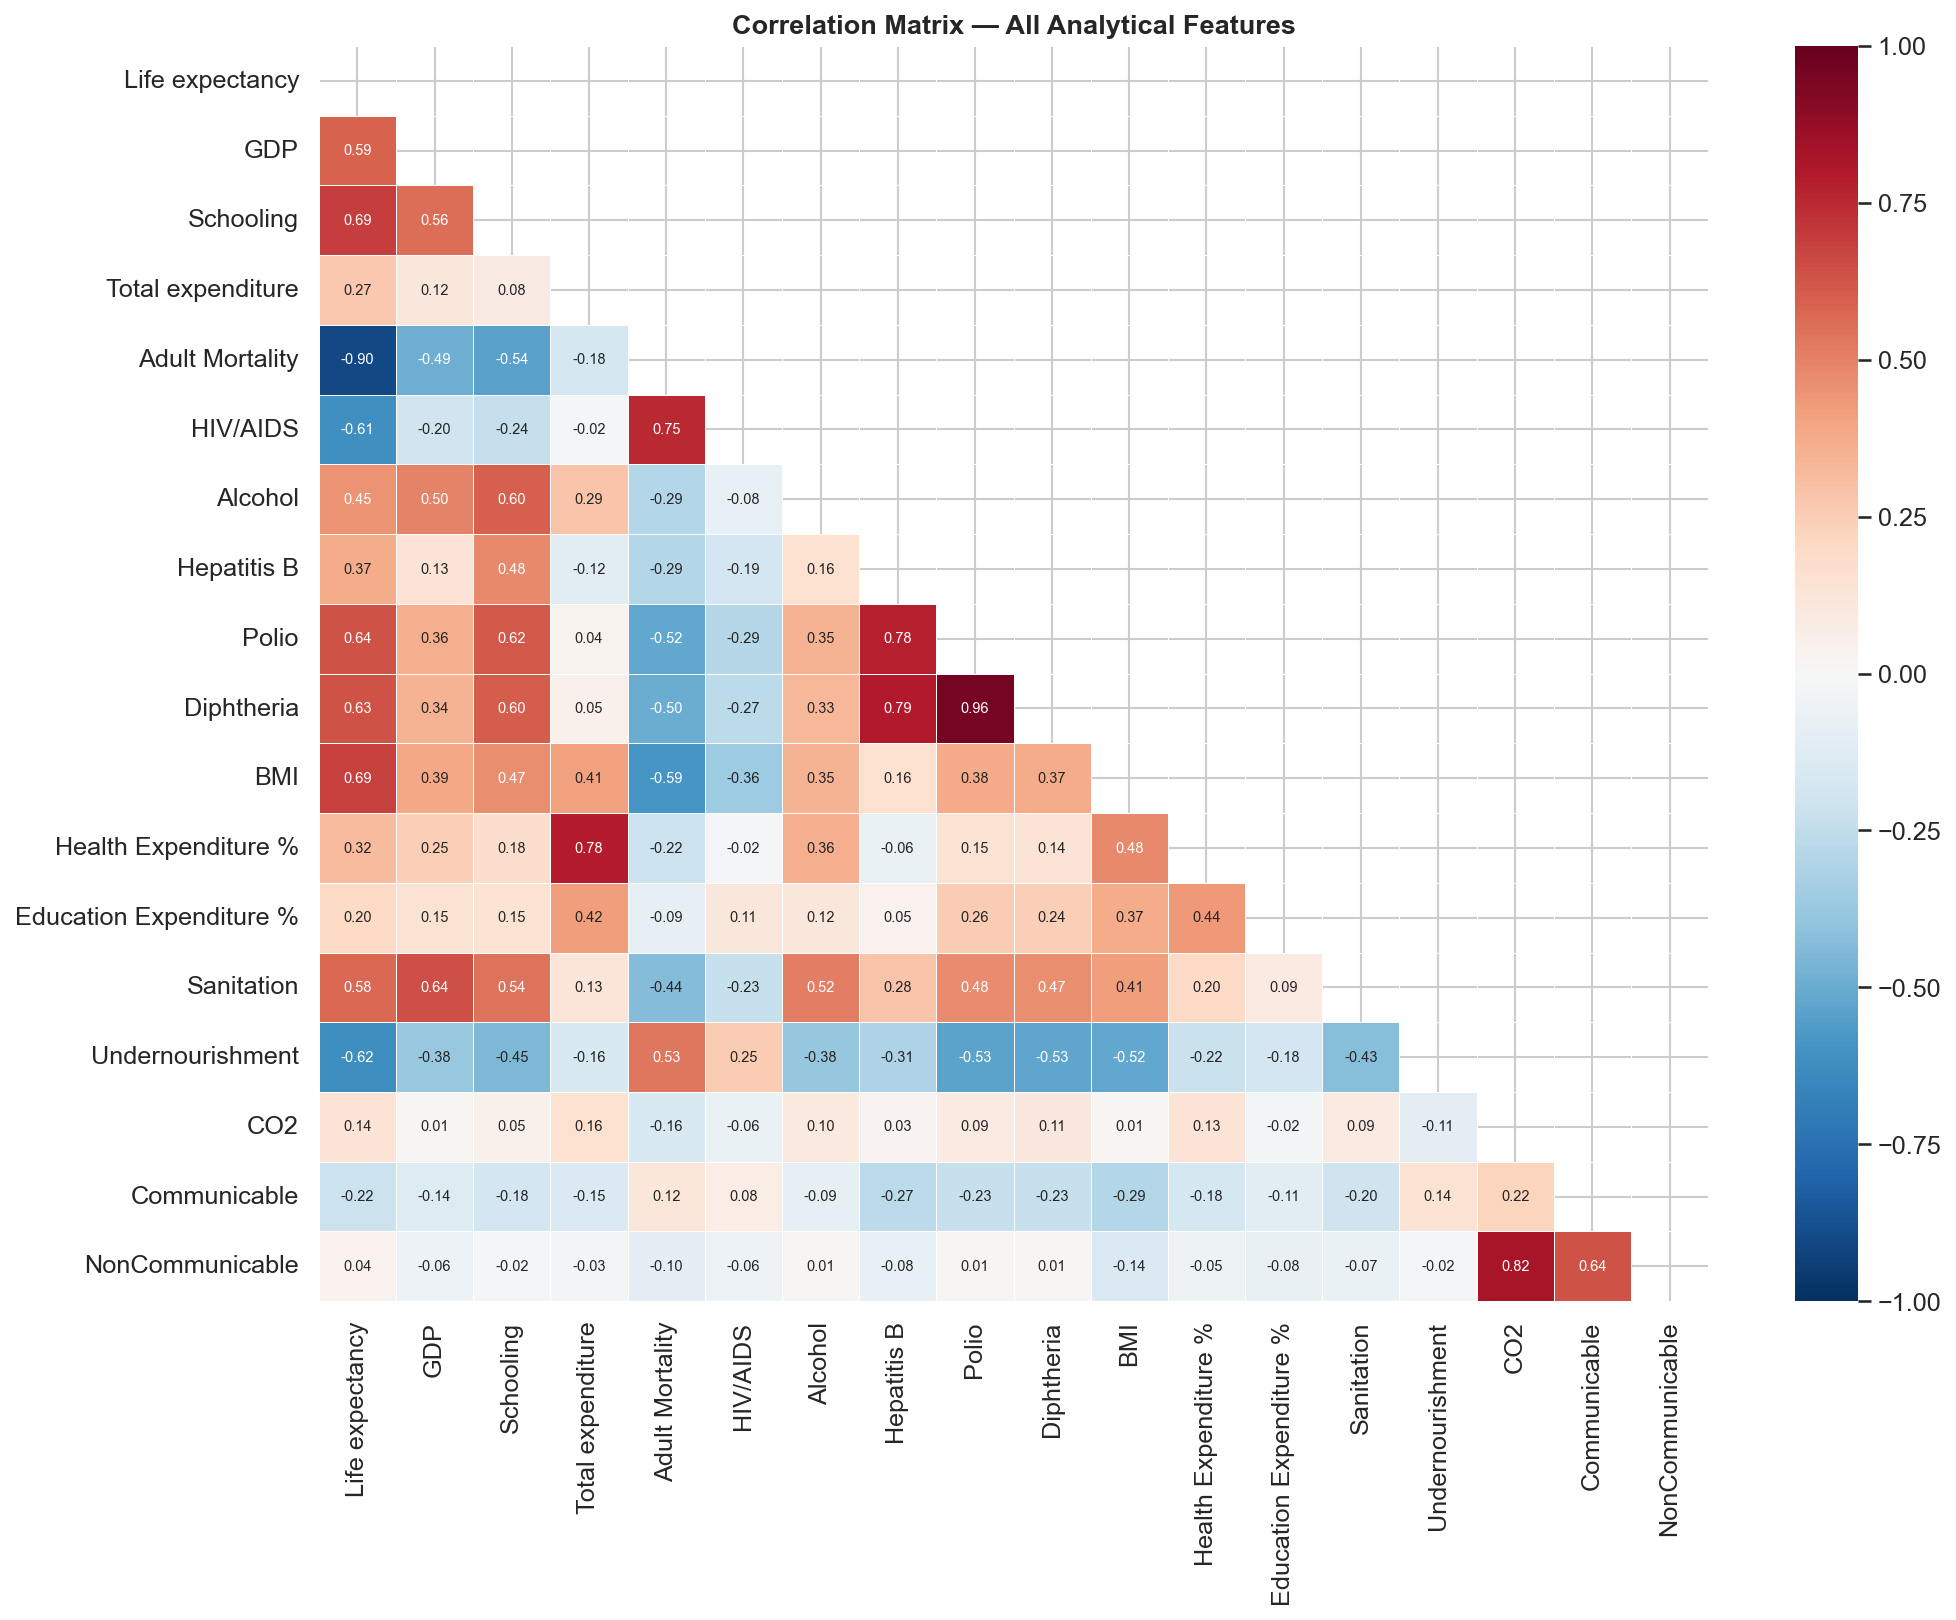

Correlations with Life Expectancy:
Adult Mortality           -0.901
Undernourishment          -0.620
HIV/AIDS                  -0.613
Communicable              -0.216
NonCommunicable            0.041
CO2                        0.137
Education Expenditure %    0.201
Total expenditure          0.269
Health Expenditure %       0.320
Hepatitis B                0.369
Alcohol                    0.451
Sanitation                 0.576
GDP                        0.591
Diphtheria                 0.633
Polio                      0.640
BMI                        0.685
Schooling                  0.692


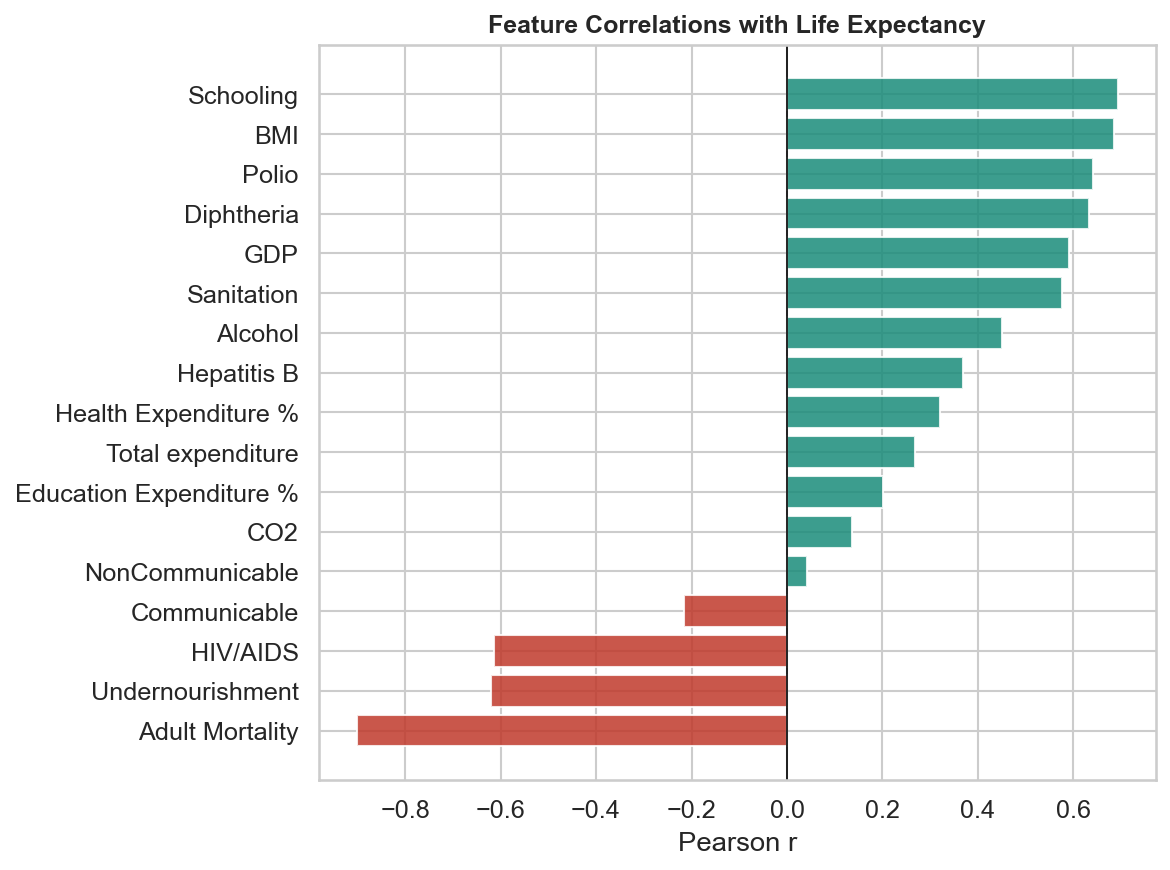

Figures saved.


In [13]:
corr = df[available].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={'size': 7}, linewidths=0.3)
ax.set_title("Correlation Matrix — All Analytical Features",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig3_correlation_matrix.png"), dpi=150)
plt.show()

# Top correlations with Life Expectancy
le_corr = corr['Life expectancy'].drop('Life expectancy').sort_values()
print("Correlations with Life Expectancy:")
print(le_corr.round(3).to_string())
le_corr.to_csv(os.path.join(TABLE_DIR, "correlations_with_life_expectancy.csv"))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 6))
colors_bar = ['#C0392B' if v < 0 else '#1A8C7A' for v in le_corr.values]
ax.barh(le_corr.index, le_corr.values, color=colors_bar, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Feature Correlations with Life Expectancy", fontsize=12, fontweight='bold')
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig4_correlations_with_LE.png"), dpi=150)
plt.show()
print("Figures saved.")


---
## Step 10 — EDA: Outlier Detection


In [14]:
print("Outlier Detection — IQR Method (1.5 x IQR):\n")
outlier_rows = []

for col in available:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]['Country'].tolist()
    outlier_rows.append({
        'Feature'     : col,
        'Q1'          : round(Q1, 2),
        'Q3'          : round(Q3, 2),
        'Lower Bound' : round(lower, 2),
        'Upper Bound' : round(upper, 2),
        'N Outliers'  : len(outliers),
        'Countries'   : ', '.join(outliers[:4]) + ('...' if len(outliers) > 4 else '')
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values('N Outliers', ascending=False)
display(outlier_df)
outlier_df.to_csv(os.path.join(TABLE_DIR, "outlier_detection.csv"), index=False)


Outlier Detection — IQR Method (1.5 x IQR):



,Feature,Q1,Q3,Lower Bound,Upper Bound,N Outliers,Countries
5,HIV/AIDS,0.10,0.94,-1.16,2.21,27,"Angola, Botswana, Burundi, Cameroon..."
15,CO2,2142.67,57199.33,-80442.33,139784.33,24,"Argentina, Australia, Brazil, Canada..."
17,NonCommunicable,410136.99,3938151.88,-4881885.34,9230174.21,23,"Bangladesh, Brazil, China, Ethiopia..."
1,GDP,844.10,7642.98,-9354.20,17841.28,22,"Australia, Austria, Belgium, Canada..."
16,Communicable,71599.42,3361191.39,-4862788.54,8295579.35,21,"Angola, Bangladesh, Brazil, Burkina Faso..."
14,Undernourishment,3.23,13.70,-12.48,29.40,11,"Afghanistan, Angola, Central African Republic,..."
13,Sanitation,37.87,61.98,1.70,98.15,5,"Austria, Kuwait, Monaco, Singapore..."
12,Education Expenditure %,3.20,5.40,-0.10,8.70,5,"Botswana, Cuba, Kiribati, Lesotho..."
8,Polio,73.50,95.87,39.95,129.42,4,"Chad, Equatorial Guinea, Somalia, Tuvalu"
9,Diphtheria,72.93,95.73,38.73,129.93,4,"Chad, Equatorial Guinea, Somalia, Tuvalu"


---
## Step 11 — EDA: Scatter Plots (Key Predictors vs Life Expectancy)


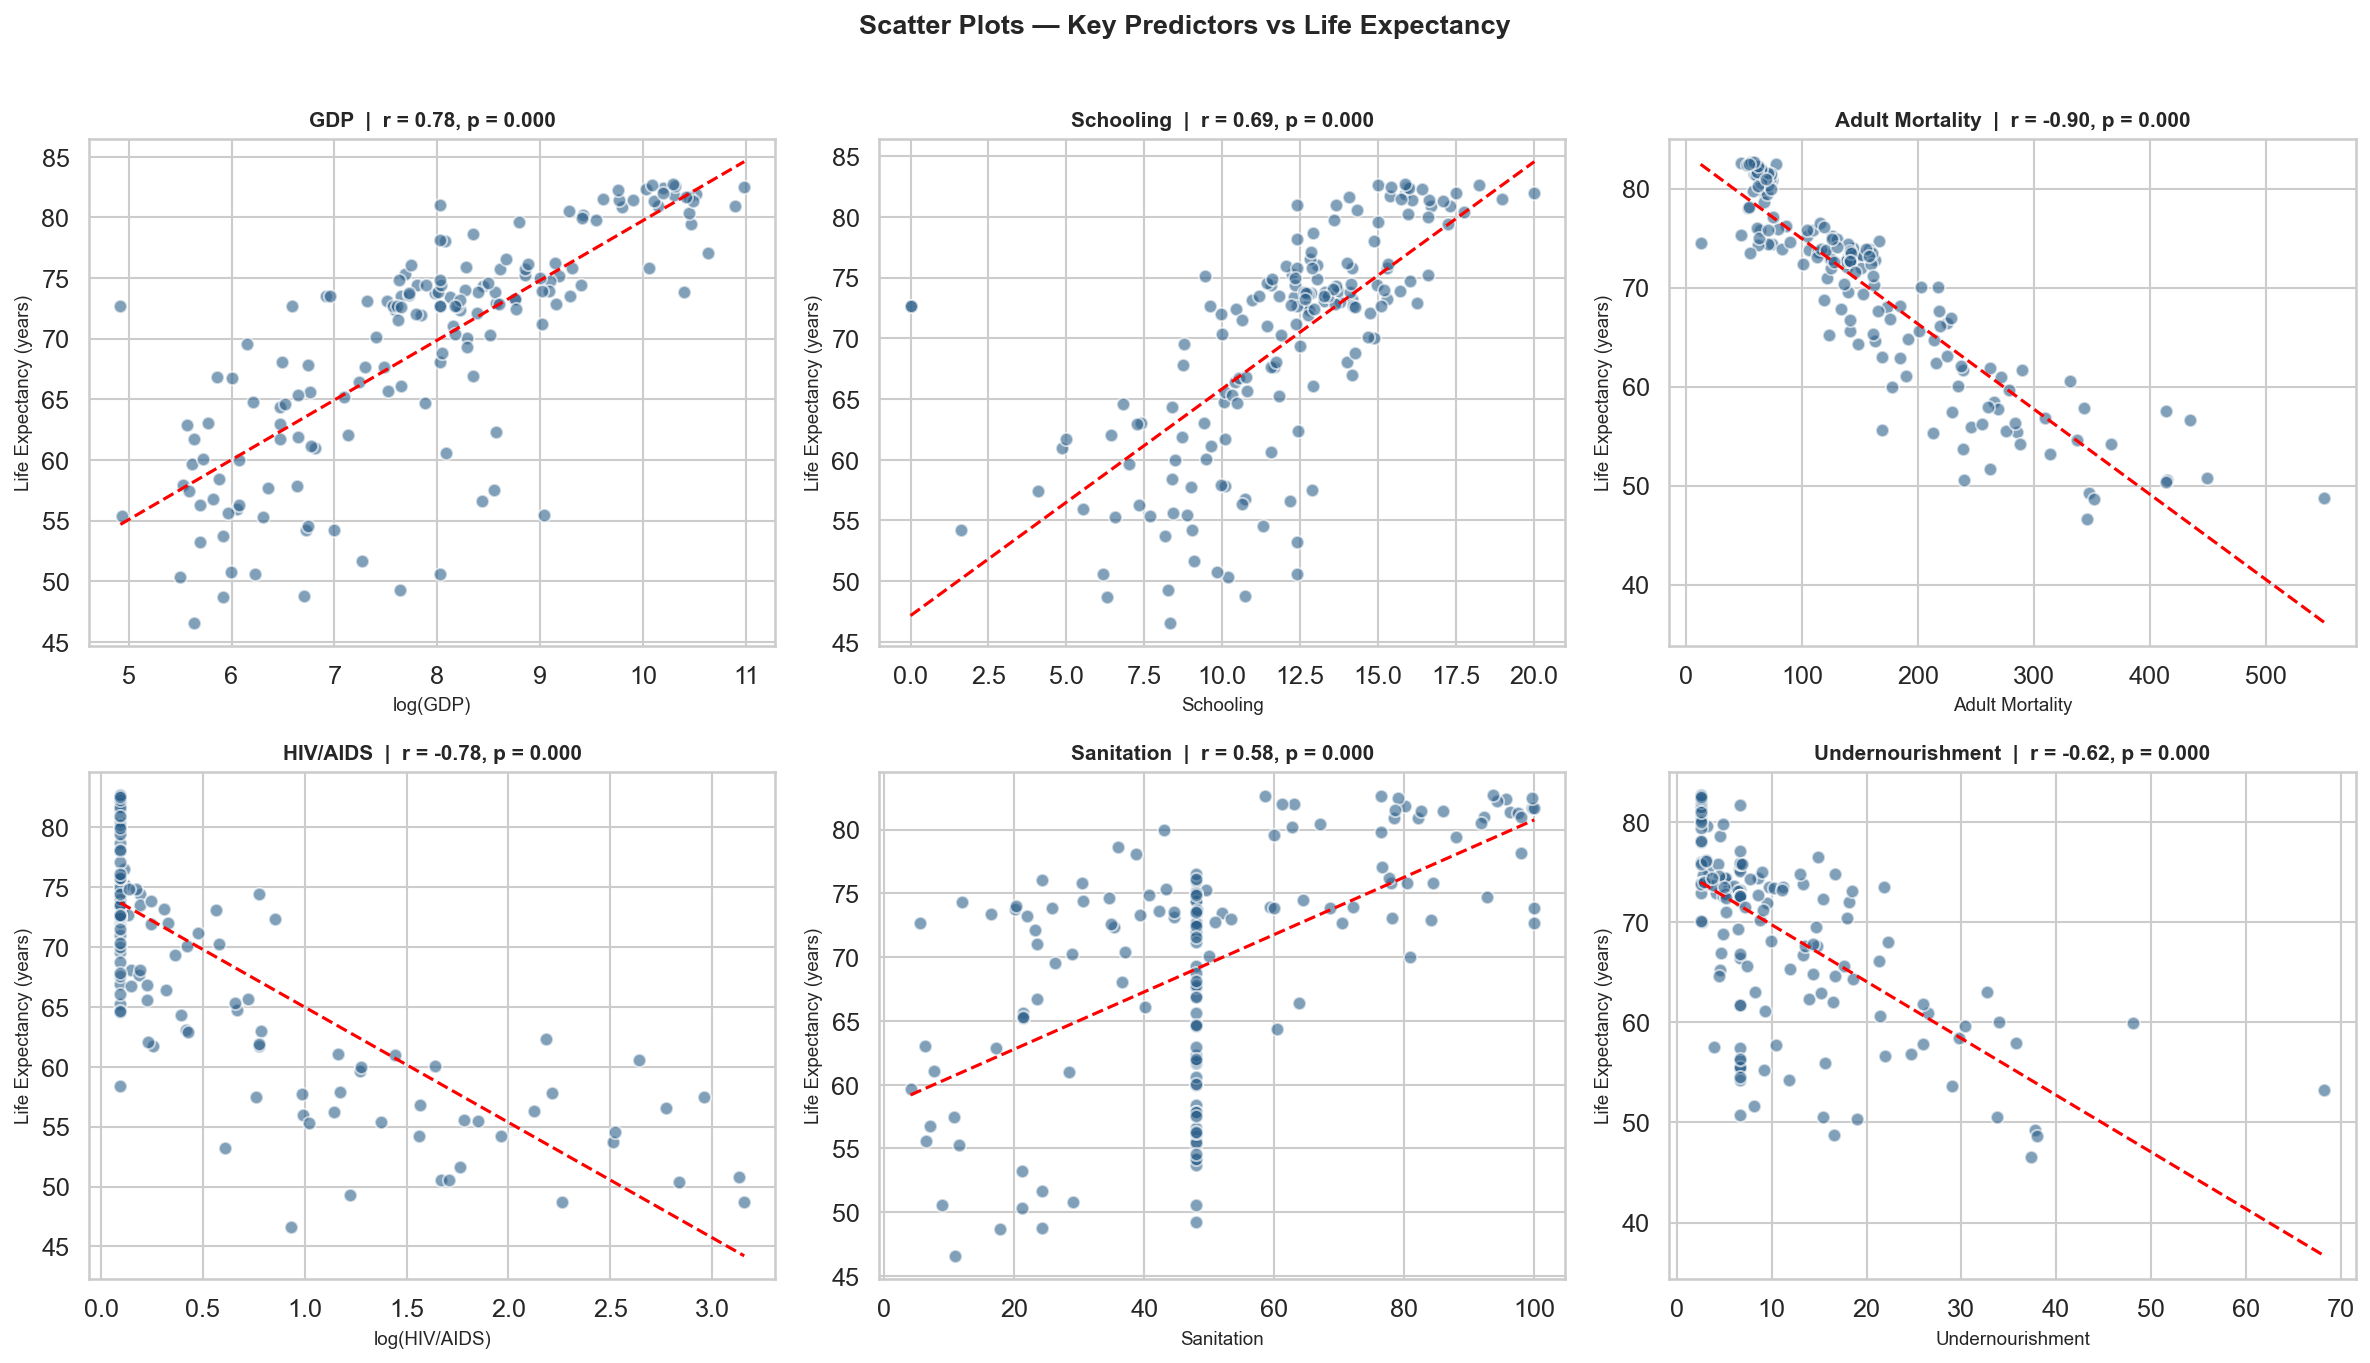

Figure saved.


In [15]:
scatter_vars = ['GDP', 'Schooling', 'Adult Mortality',
                'HIV/AIDS', 'Sanitation', 'Undernourishment']
scatter_vars = [v for v in scatter_vars if v in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(scatter_vars):
    x = np.log1p(df[var]) if var in ['GDP', 'CO2', 'HIV/AIDS'] else df[var]
    axes[i].scatter(x, df['Life expectancy'],
                    color='#2C5F8A', alpha=0.6, s=40, edgecolors='white')
    z = np.polyfit(x.dropna(), df.loc[x.dropna().index, 'Life expectancy'], 1)
    p = np.poly1d(z)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(xline, p(xline), color='red', linewidth=1.5, linestyle='--')
    r, pval = stats.pearsonr(x.dropna(), df.loc[x.dropna().index, 'Life expectancy'])
    xlabel = f"log({var})" if var in ['GDP', 'CO2', 'HIV/AIDS'] else var
    axes[i].set_xlabel(xlabel, fontsize=9)
    axes[i].set_ylabel("Life Expectancy (years)", fontsize=9)
    axes[i].set_title(f"{var}  |  r = {r:.2f}, p = {pval:.3f}",
                      fontsize=10, fontweight='bold')

plt.suptitle("Scatter Plots — Key Predictors vs Life Expectancy",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig5_scatter_plots.png"), dpi=150)
plt.show()
print("Figure saved.")


---
## Step 12 — Regression: Full Model (H1a)


In [16]:
REG_VARS = ['GDP', 'Schooling', 'Total expenditure', 'Adult Mortality',
            'HIV/AIDS', 'Sanitation', 'Undernourishment',
            'Education Expenditure %', 'BMI']
REG_VARS = [v for v in REG_VARS if v in df.columns]

X_reg = df[REG_VARS].copy()
y_reg = df['Life expectancy'].copy()

# Log-transform skewed variables
for col in ['GDP', 'CO2', 'HIV/AIDS']:
    if col in X_reg.columns:
        X_reg[col] = np.log1p(X_reg[col])

X_full = sm.add_constant(X_reg)
model_full = sm.OLS(y_reg, X_full).fit()
print("=== FULL MODEL ===")
print(model_full.summary())

with open(os.path.join(TABLE_DIR, "regression_full_model.txt"), "w") as f:
    f.write(model_full.summary().as_text())


=== FULL MODEL ===
                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     215.9
Date:                Sat, 16 May 2026   Prob (F-statistic):           3.15e-82
Time:                        16:07:24   Log-Likelihood:                -380.09
No. Observations:                 163   AIC:                             780.2
Df Residuals:                     153   BIC:                             811.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const  

---
## Step 13 — VIF Check (Full Model)


In [17]:
vif_full = pd.DataFrame({
    'Variable': X_reg.columns,
    'VIF': [variance_inflation_factor(X_reg.values, i)
            for i in range(X_reg.shape[1])]
}).sort_values('VIF', ascending=False)

print("VIF — Full Model:")
display(vif_full.round(2))
vif_full.to_csv(os.path.join(TABLE_DIR, "vif_full_model.csv"), index=False)

print("\nInterpretation:")
for _, row in vif_full.iterrows():
    if row['VIF'] > 10:
        status = "HIGH multicollinearity — consider removing"
    elif row['VIF'] > 5:
        status = "Moderate multicollinearity"
    else:
        status = "Acceptable"
    print(f"  {row['Variable']:<30} VIF = {row['VIF']:.2f}  ->  {status}")


VIF — Full Model:


,Variable,VIF
0,GDP,56.26
1,Schooling,29.31
8,BMI,15.34
3,Adult Mortality,11.71
2,Total expenditure,10.94
5,Sanitation,9.78
7,Education Expenditure %,8.37
4,HIV/AIDS,4.79
6,Undernourishment,3.03



Interpretation:
  GDP                            VIF = 56.26  ->  HIGH multicollinearity — consider removing
  Schooling                      VIF = 29.31  ->  HIGH multicollinearity — consider removing
  BMI                            VIF = 15.34  ->  HIGH multicollinearity — consider removing
  Adult Mortality                VIF = 11.71  ->  HIGH multicollinearity — consider removing
  Total expenditure              VIF = 10.94  ->  HIGH multicollinearity — consider removing
  Sanitation                     VIF = 9.78  ->  Moderate multicollinearity
  Education Expenditure %        VIF = 8.37  ->  Moderate multicollinearity
  HIV/AIDS                       VIF = 4.79  ->  Acceptable
  Undernourishment               VIF = 3.03  ->  Acceptable


---
## Step 14 — Regression: Refined Model

Variables with VIF > 10 are removed to resolve multicollinearity.


In [18]:
# Iterative VIF removal — remove highest VIF one at a time
X_iter = X_reg.copy()

while True:
    vif_iter = pd.DataFrame({
        'Variable': X_iter.columns,
        'VIF': [variance_inflation_factor(X_iter.values, i)
                for i in range(X_iter.shape[1])]
    }).sort_values('VIF', ascending=False)
    
    max_vif = vif_iter.iloc[0]['VIF']
    max_var = vif_iter.iloc[0]['Variable']
    
    if max_vif > 10:
        print(f"Removing '{max_var}' (VIF = {max_vif:.2f})")
        X_iter = X_iter.drop(columns=[max_var])
    else:
        print("\nAll VIF values acceptable (< 10)")
        break

print("\nFinal variables retained:")
print(list(X_iter.columns))

# Refined model
X_refined = sm.add_constant(X_iter)
model_refined = sm.OLS(y_reg, X_refined).fit()
print("\n=== REFINED MODEL ===")
print(model_refined.summary())

with open(os.path.join(TABLE_DIR, "regression_refined_model.txt"), "w") as f:
    f.write(model_refined.summary().as_text())


Removing 'GDP' (VIF = 56.26)
Removing 'Schooling' (VIF = 15.44)
Removing 'BMI' (VIF = 11.99)
Removing 'Adult Mortality' (VIF = 10.72)

All VIF values acceptable (< 10)

Final variables retained:
['Total expenditure', 'HIV/AIDS', 'Sanitation', 'Undernourishment', 'Education Expenditure %']

=== REFINED MODEL ===
                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     125.6
Date:                Sat, 16 May 2026   Prob (F-statistic):           5.10e-53
Time:                        16:07:24   Log-Likelihood:                -462.21
No. Observations:                 163   AIC:                             936.4
Df Residuals:                     157   BIC:                             955.0
Df Model:                           5                  

---
## Step 15 — Regression Diagnostics


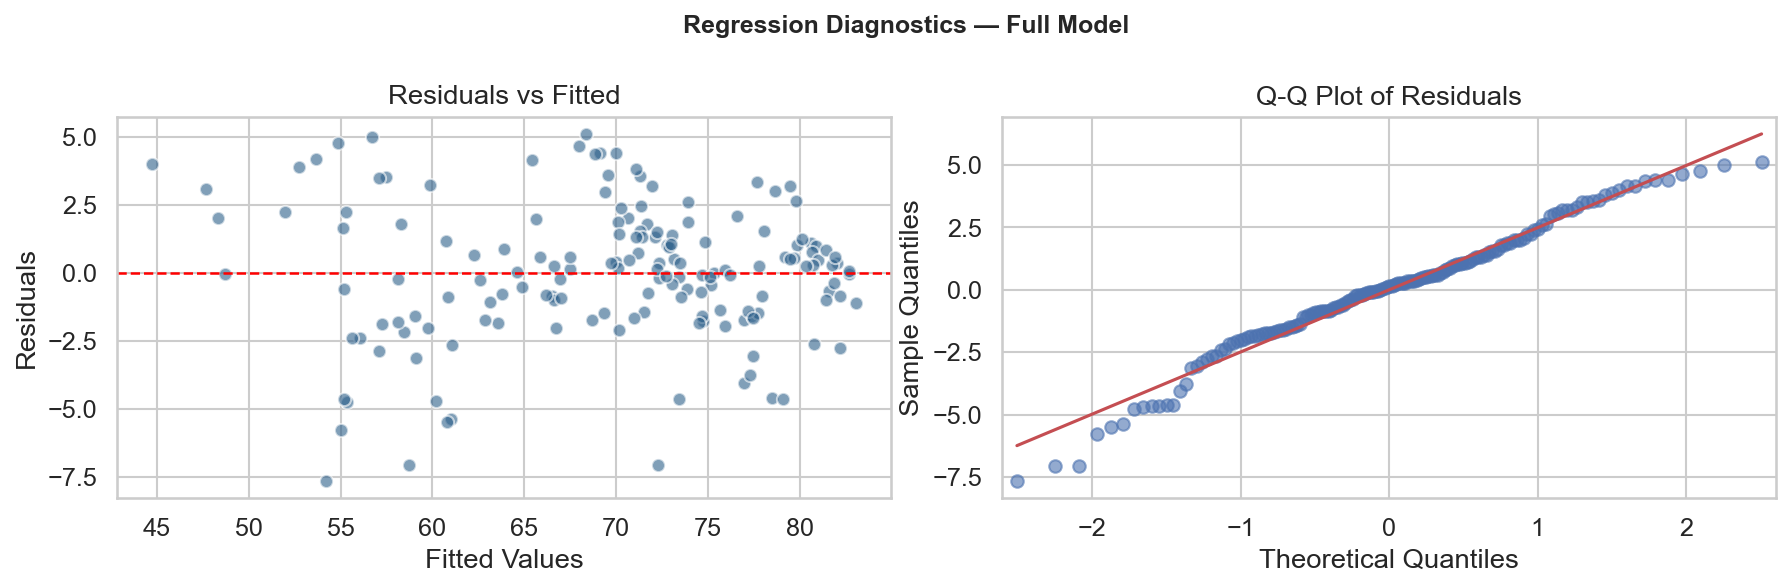

Figure saved.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fitted    = model_full.fittedvalues
residuals = model_full.resid

axes[0].scatter(fitted, residuals, color='#2C5F8A', alpha=0.6, s=40, edgecolors='white')
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.6)
axes[1].set_title("Q-Q Plot of Residuals")

plt.suptitle("Regression Diagnostics — Full Model",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig6_regression_diagnostics.png"), dpi=150)
plt.show()
print("Figure saved.")


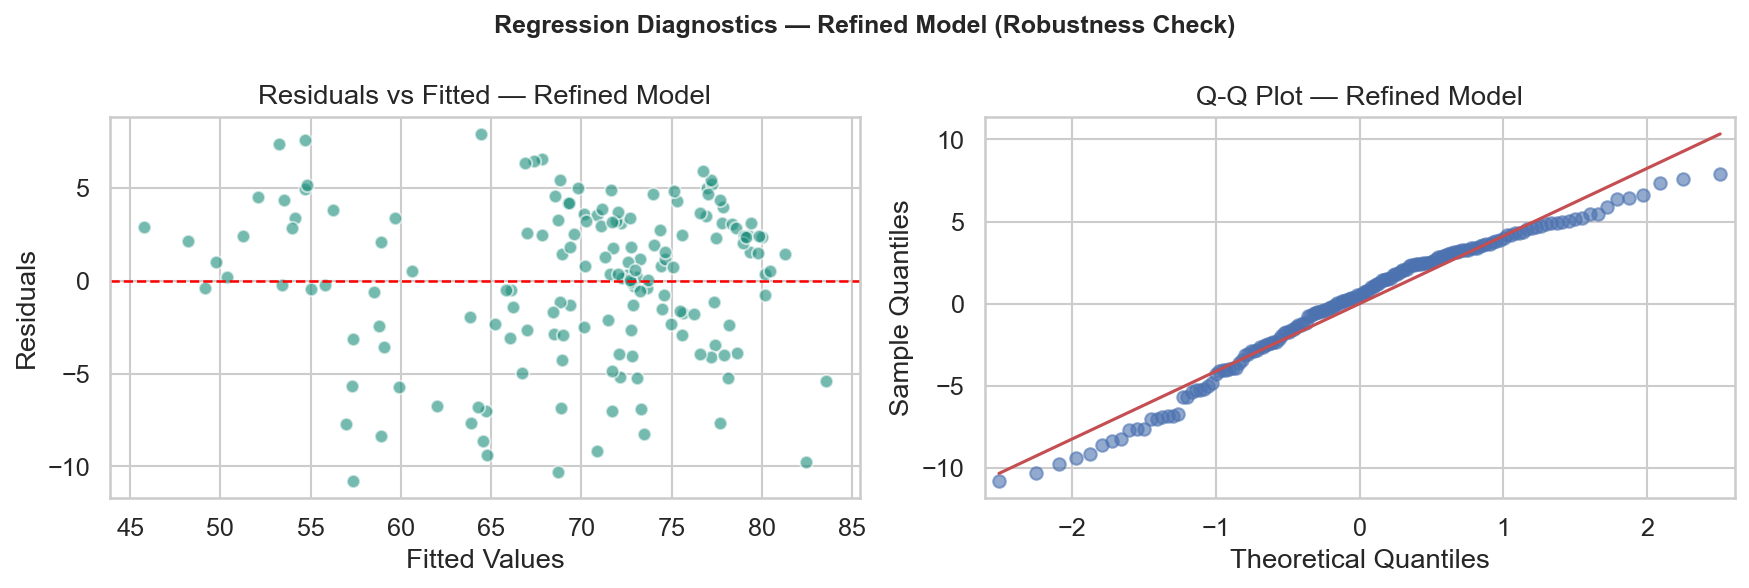

=== Refined Model Diagnostics ===
Mean of residuals     : -0.0000  (should be ~0)
Std of residuals      : 4.1363
Min residual          : -10.77
Max residual          : 7.92
Durbin-Watson         : 2.029  (should be ~2)
Jarque-Bera statistic : 9.469, p-value = 0.0088
  -> Residuals deviate from normality at 5% level

Figure saved.


In [20]:
# ──────────────────────────────────────────────────────────────
# Step 15b — Regression Diagnostics for REFINED Model
# ──────────────────────────────────────────────────────────────
# Robustness check: verify that the refined model also satisfies
# regression assumptions, not just the full model.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fitted_ref    = model_refined.fittedvalues
residuals_ref = model_refined.resid

# Plot 1: Residuals vs Fitted
axes[0].scatter(fitted_ref, residuals_ref, color='#1A8C7A', 
                alpha=0.6, s=40, edgecolors='white')
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted — Refined Model")

# Plot 2: Q-Q Plot
sm.qqplot(residuals_ref, line='s', ax=axes[1], alpha=0.6)
axes[1].set_title("Q-Q Plot — Refined Model")

plt.suptitle("Regression Diagnostics — Refined Model (Robustness Check)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig6b_regression_diagnostics_refined.png"), dpi=150)
plt.show()

# Print diagnostic statistics
print("=== Refined Model Diagnostics ===")
print(f"Mean of residuals     : {residuals_ref.mean():.4f}  (should be ~0)")
print(f"Std of residuals      : {residuals_ref.std():.4f}")
print(f"Min residual          : {residuals_ref.min():.2f}")
print(f"Max residual          : {residuals_ref.max():.2f}")
print(f"Durbin-Watson         : {sm.stats.stattools.durbin_watson(residuals_ref):.3f}  (should be ~2)")

# Normality test
from scipy.stats import jarque_bera
jb_stat, jb_pval = jarque_bera(residuals_ref)
print(f"Jarque-Bera statistic : {jb_stat:.3f}, p-value = {jb_pval:.4f}")
if jb_pval < 0.05:
    print("  -> Residuals deviate from normality at 5% level")
else:
    print("  -> Residuals consistent with normality")

print("\nFigure saved.")

---
## Step 16 — PCA: Variance Explained


In [21]:
PCA_FEATURES = [f for f in available if f != 'Life expectancy']

# Log-transform skewed variables before PCA
df_pca = df[PCA_FEATURES].copy()
for col in ['GDP', 'CO2', 'Communicable', 'NonCommunicable']:
    if col in df_pca.columns:
        df_pca[col] = np.log1p(df_pca[col])

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# Full PCA to check eigenvalues
pca_full = PCA()
pca_full.fit(X_scaled)

ev       = pca_full.explained_variance_
ev_ratio = pca_full.explained_variance_ratio_
cum_var  = np.cumsum(ev_ratio)

print(f"{'Component':<12} {'Eigenvalue':<12} {'Variance %':<12} {'Cumulative %':<14} {'Kaiser'}")
print("-" * 58)
for i, (e, v, c) in enumerate(zip(ev, ev_ratio, cum_var)):
    keep = "Keep" if e > 1 else "Drop"
    print(f"  PC{i+1:<8}   {e:.3f}{'':>6}   {v*100:.1f}%{'':>5}   {c*100:.1f}%{'':>7}   {keep}")
    if c > 0.92:
        break

n_kaiser = int(np.sum(ev > 1))
n_85     = int(np.argmax(cum_var >= 0.85)) + 1
n_comp   = max(n_kaiser, n_85)
print(f"Kaiser criterion (eigenvalue > 1) : {n_kaiser} components")
print(f"85% variance threshold            : {n_85} components")
print(f"Components selected               : {n_comp} (by 85% threshold rule)")
print(f"Variance explained                : {cum_var[n_comp-1]:.1%}")
print(f"Note: Kaiser alone would retain only {n_kaiser} components (PC1-PC{n_kaiser}, all with eigenvalue > 1)")


Component    Eigenvalue   Variance %   Cumulative %   Kaiser
----------------------------------------------------------
  PC1          6.459         37.8%        37.8%          Keep
  PC2          2.829         16.5%        54.3%          Keep
  PC3          2.006         11.7%        66.0%          Keep
  PC4          1.477         8.6%        74.7%          Keep
  PC5          1.070         6.3%        80.9%          Keep
  PC6          0.712         4.2%        85.1%          Drop
  PC7          0.575         3.4%        88.4%          Drop
  PC8          0.485         2.8%        91.3%          Drop
  PC9          0.383         2.2%        93.5%          Drop
Kaiser criterion (eigenvalue > 1) : 5 components
85% variance threshold            : 6 components
Components selected               : 6 (by 85% threshold rule)
Variance explained                : 85.1%
Note: Kaiser alone would retain only 5 components (PC1-PC5, all with eigenvalue > 1)


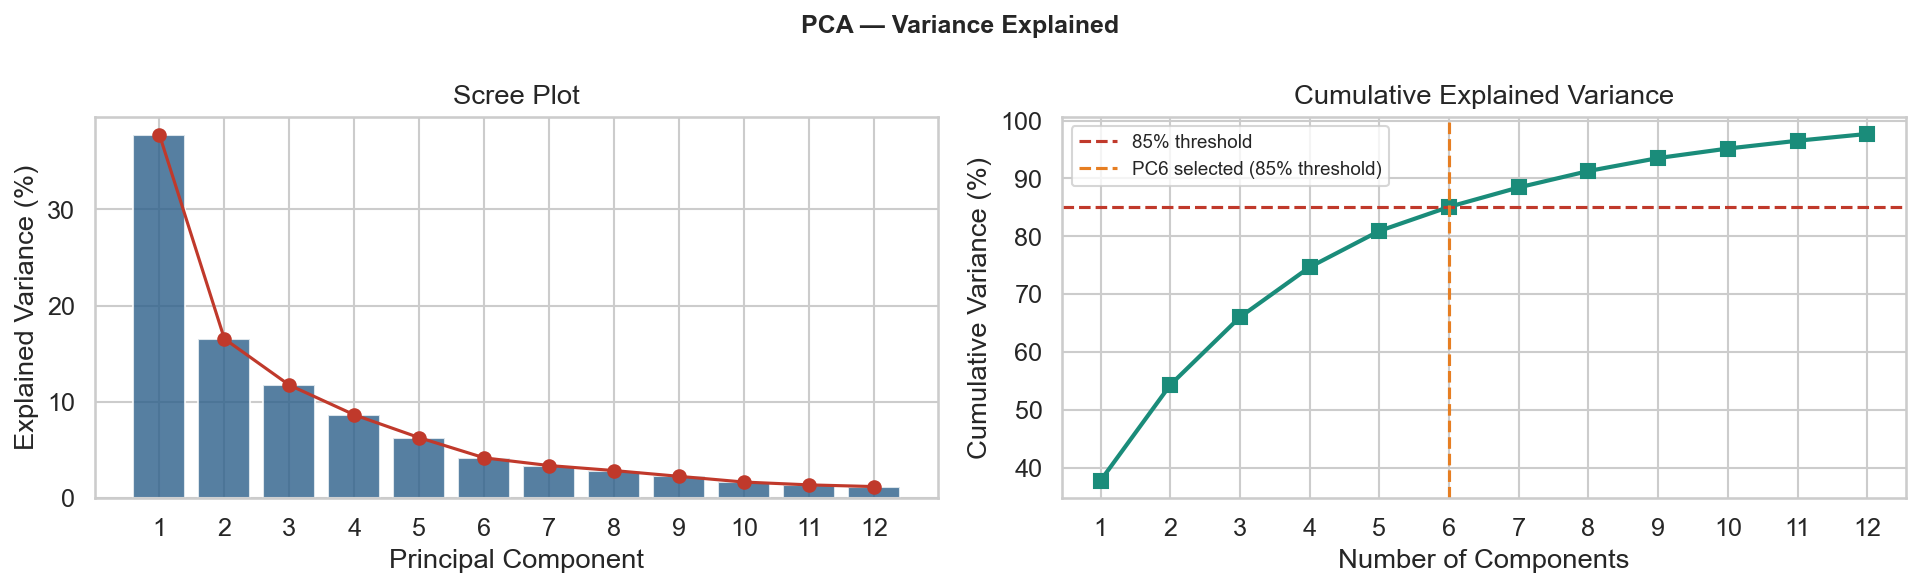

Figure saved.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

n_show = 12
axes[0].bar(range(1, n_show+1), ev_ratio[:n_show]*100,
            color='#2C5F8A', alpha=0.8, edgecolor='white')
axes[0].plot(range(1, n_show+1), ev_ratio[:n_show]*100,
             'o-', color='#C0392B', markersize=6)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot")
axes[0].set_xticks(range(1, n_show+1))

axes[1].plot(range(1, n_show+1), cum_var[:n_show]*100,
             's-', color='#1A8C7A', markersize=7, linewidth=2)
axes[1].axhline(85, color='#C0392B', linestyle='--', label='85% threshold')
axes[1].axvline(n_comp, color='#E67E22', linestyle='--',
                label=f'PC{n_comp} selected (85% threshold)')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xticks(range(1, n_show+1))
axes[1].legend(fontsize=9)

plt.suptitle("PCA — Variance Explained", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig7_pca_variance.png"), dpi=150)
plt.show()
print("Figure saved.")


---
## Step 17 — PCA: Loadings Matrix


PCA Loadings Matrix:
                           PC1    PC2    PC3    PC4    PC5    PC6
GDP                      0.326  0.034  0.109 -0.156  0.304  0.214
Schooling                0.314  0.138  0.034  0.036  0.219 -0.048
Total expenditure        0.117 -0.327  0.408  0.094 -0.281 -0.277
Adult Mortality         -0.302 -0.016  0.068  0.378  0.298 -0.059
HIV/AIDS                -0.179 -0.024  0.183  0.523  0.440  0.125
Alcohol                  0.239  0.069  0.316  0.021  0.357 -0.338
Hepatitis B              0.214  0.168 -0.349  0.373 -0.143 -0.273
Polio                    0.315  0.130 -0.206  0.312 -0.159 -0.039
Diphtheria               0.310  0.143 -0.198  0.325 -0.176 -0.041
BMI                      0.286 -0.239  0.068 -0.155 -0.038  0.196
Health Expenditure %     0.152 -0.312  0.398  0.136 -0.239 -0.290
Education Expenditure %  0.125 -0.271  0.160  0.371 -0.148  0.628
Sanitation               0.273  0.075  0.078 -0.068  0.331 -0.157
Undernourishment        -0.281  0.013  0.025  0.035 -0.

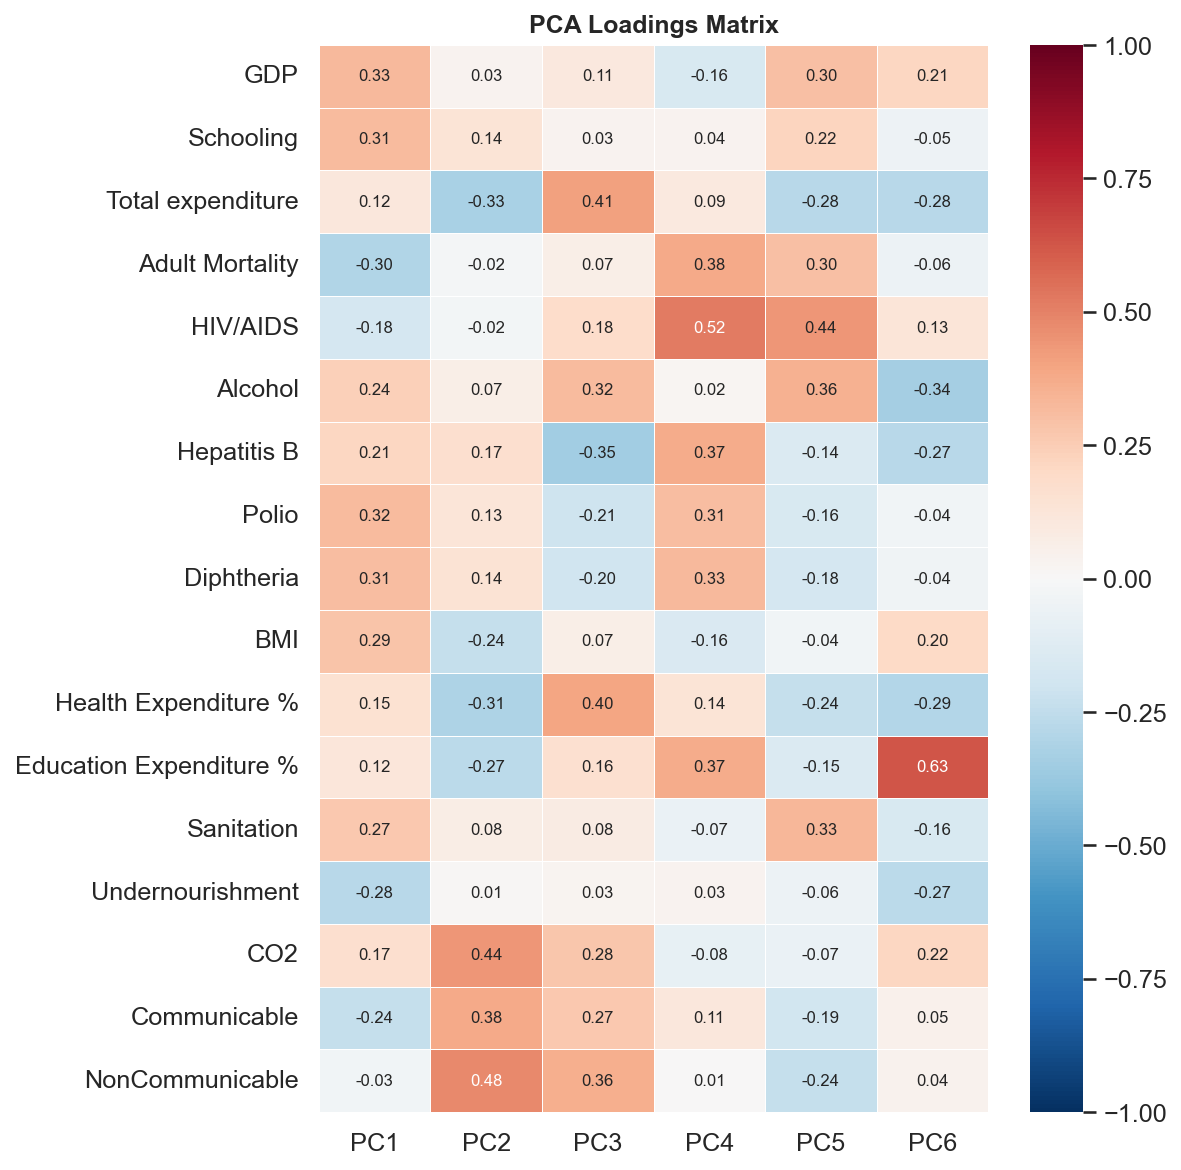

Figure saved.


In [23]:
pca_final    = PCA(n_components=n_comp)
X_pca_scores = pca_final.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca_final.components_.T,
    index=PCA_FEATURES,
    columns=[f'PC{i+1}' for i in range(n_comp)]
)

print("PCA Loadings Matrix:")
print(loadings.round(3).to_string())
loadings.to_csv(os.path.join(TABLE_DIR, "pca_loadings.csv"))

fig, ax = plt.subplots(figsize=(max(8, n_comp*1.3), 8))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.4)
ax.set_title("PCA Loadings Matrix", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig8_pca_loadings.png"), dpi=150)
plt.show()
print("Figure saved.")


---
## Step 18 — K-Means: Optimal k Selection


 k  Inertia  Silhouette
 2 1573.190       0.343
 3 1309.396       0.258
 4 1114.160       0.268
 5  970.930       0.288
 6  843.934       0.265
 7  772.378       0.251
 8  712.306       0.258


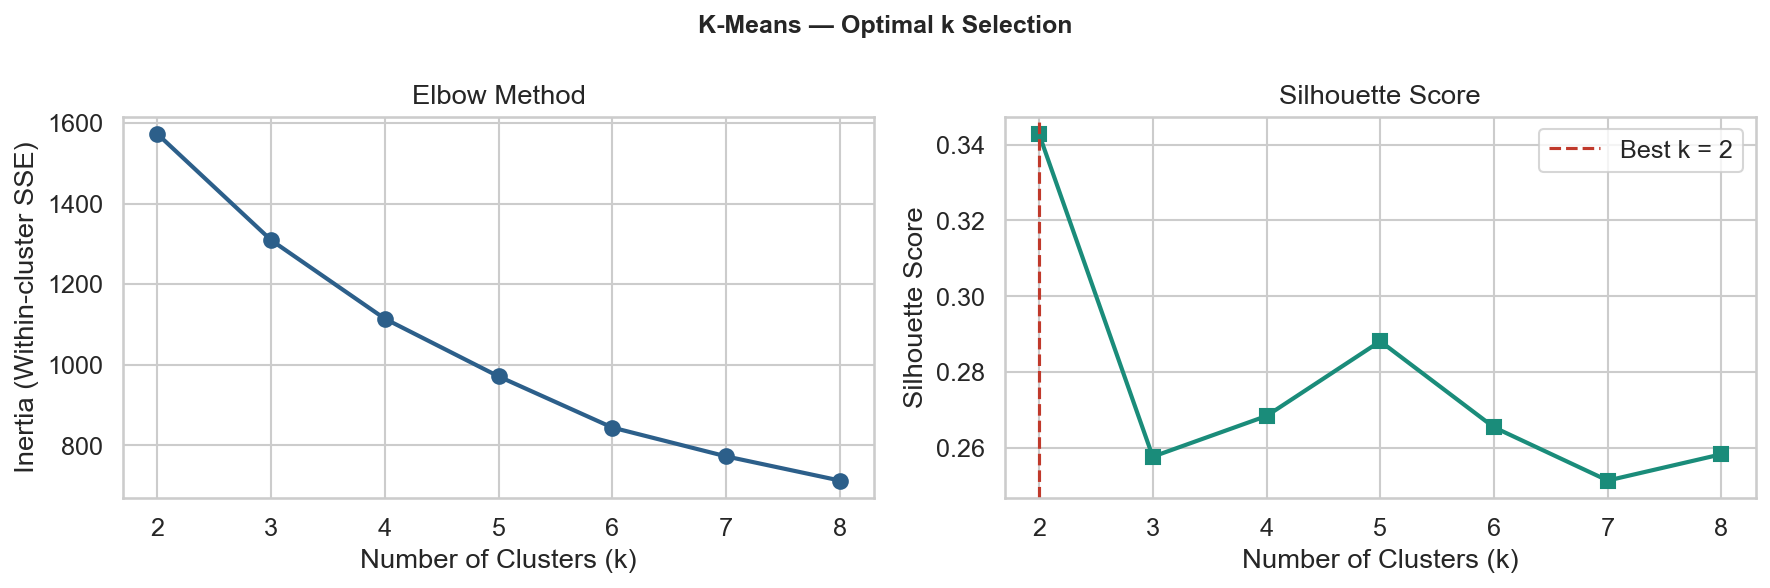

Best k by Silhouette = 2


In [24]:
K_RANGE     = range(2, 9)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_scores)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca_scores, labels))

cluster_eval = pd.DataFrame({
    'k'         : list(K_RANGE),
    'Inertia'   : inertias,
    'Silhouette': silhouettes
})
print(cluster_eval.round(3).to_string(index=False))
cluster_eval.to_csv(os.path.join(TABLE_DIR, "cluster_evaluation.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_RANGE), inertias, 'o-', color='#2C5F8A', markersize=7, linewidth=2)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (Within-cluster SSE)")
axes[0].set_title("Elbow Method")
axes[0].set_xticks(list(K_RANGE))

best_k = list(K_RANGE)[np.argmax(silhouettes)]
axes[1].plot(list(K_RANGE), silhouettes, 's-', color='#1A8C7A', markersize=7, linewidth=2)
axes[1].axvline(best_k, color='#C0392B', linestyle='--', label=f'Best k = {best_k}')
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.suptitle("K-Means — Optimal k Selection", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig9_kmeans_selection.png"), dpi=150)
plt.show()
print(f"Best k by Silhouette = {best_k}")




In [25]:
# Decision: k=3 selected based on combined criteria:
# - k=2 has the highest silhouette score (0.343), but gives a broad binary split
#   with limited policy relevance (only high vs. low development).
# - k=3 is selected as a deliberate trade-off between internal validity
#   and substantive interpretability.
# - k=3 separates a meaningful transitional archetype (middle-income countries)
#   that does not appear in the binary k=2 solution.
# - Therefore, k=3 is not the statistical optimum, but it is the
#   selected analytical solution, consistent with prior clustering literature
#   that balances statistical and interpretive criteria (Korir, 2024).
# Note: The silhouette difference (0.343 vs 0.258) represents a 25% drop
#       and is acknowledged as a trade-off, not a marginal difference.

best_k = 3
print(f"Selected k = {best_k}")
print()
print("Justification for k=3 over k=2:")
print(f"  - k=2 silhouette: {silhouettes[list(K_RANGE).index(2)]:.3f} (highest, but binary split only)")
print(f"  - k=3 silhouette: {silhouettes[list(K_RANGE).index(3)]:.3f} (accepted trade-off)")
print(f"  - Silhouette drop: {silhouettes[list(K_RANGE).index(2)] - silhouettes[list(K_RANGE).index(3)]:.3f} (25% — acknowledged, not marginal)")
print(f"  - k=3 produces three interpretable global health archetypes")
print(f"  - Elbow method shows inflection point at k=3")

Selected k = 3

Justification for k=3 over k=2:
  - k=2 silhouette: 0.343 (highest, but binary split only)
  - k=3 silhouette: 0.258 (accepted trade-off)
  - Silhouette drop: 0.085 (25% — acknowledged, not marginal)
  - k=3 produces three interpretable global health archetypes
  - Elbow method shows inflection point at k=3


In [26]:
# ──────────────────────────────────────────────────────────────
# Step 18c — Robustness Check: Regression WITHOUT Adult Mortality
# ──────────────────────────────────────────────────────────────
# Adult Mortality is mathematically related to Life Expectancy
# (both quantify mortality patterns). This near-tautological
# relationship can artificially inflate R². This check confirms
# that explanatory power persists when Adult Mortality is excluded.

REG_VARS_NO_AM = [v for v in REG_VARS if v != 'Adult Mortality']
print(f"Variables in robustness check (Adult Mortality removed):")
print(f"  {REG_VARS_NO_AM}")
print()

X_no_am = df[REG_VARS_NO_AM].copy()

# Apply same log-transforms as before
for col in ['GDP', 'CO2', 'HIV/AIDS']:
    if col in X_no_am.columns:
        X_no_am[col] = np.log1p(X_no_am[col])

X_no_am_const = sm.add_constant(X_no_am)
model_no_am = sm.OLS(y_reg, X_no_am_const).fit()

print("=== ROBUSTNESS CHECK: Without Adult Mortality ===")
print(model_no_am.summary())

# Save
with open(os.path.join(TABLE_DIR, "regression_robustness_no_AM.txt"), "w") as f:
    f.write(model_no_am.summary().as_text())

# Comparison table
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Model':<45} {'R-squared':<12}")
print("-" * 60)
print(f"{'Full model (with Adult Mortality)':<45} {model_full.rsquared:.3f}")
print(f"{'Robustness check (no Adult Mortality)':<45} {model_no_am.rsquared:.3f}")
print(f"{'Refined model (VIF-cleaned)':<45} {model_refined.rsquared:.3f}")
print()
print("Interpretation:")
drop = model_full.rsquared - model_no_am.rsquared
print(f"  Removing Adult Mortality reduces R² by {drop:.3f} ({drop*100:.1f} percentage points)")
if model_no_am.rsquared > 0.70:
    print(f"  R² remains substantial (0.883), suggesting socioeconomic")
    print(f"  predictors carry explanatory power beyond the shared variance")
    print(f"  with Adult Mortality.")
else:
    print(f"  R² drops substantially without Adult Mortality.")

print(f"Selected k = {best_k} (interpretability trade-off; k=2 has highest silhouette = {silhouettes[list(K_RANGE).index(2)]:.3f})")
print(f"Selected k={best_k} silhouette = {silhouettes[list(K_RANGE).index(best_k)]:.3f}")
print(f"Silhouette drop: {silhouettes[list(K_RANGE).index(2)] - silhouettes[list(K_RANGE).index(best_k)]:.3f} ({(1 - silhouettes[list(K_RANGE).index(best_k)]/silhouettes[list(K_RANGE).index(2)])*100:.0f}% — acknowledged trade-off)")

Variables in robustness check (Adult Mortality removed):
  ['GDP', 'Schooling', 'Total expenditure', 'HIV/AIDS', 'Sanitation', 'Undernourishment', 'Education Expenditure %', 'BMI']

=== ROBUSTNESS CHECK: Without Adult Mortality ===
                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     145.7
Date:                Sat, 16 May 2026   Prob (F-statistic):           8.15e-68
Time:                        16:07:31   Log-Likelihood:                -418.31
No. Observations:                 163   AIC:                             854.6
Df Residuals:                     154   BIC:                             882.5
Df Model:                           8                                         
Covariance Type:            nonrobust                    

---
## Step 19 — K-Means: Final Clustering


In [27]:
km_final     = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_pca_scores) + 1  # 1-indexed

print("Cluster Distribution:")
print(df['Cluster'].value_counts().sort_index().to_string())

print("\nSample countries per cluster:")
for c in sorted(df['Cluster'].unique()):
    countries = df[df['Cluster']==c]['Country'].tolist()
    print(f"\nCluster {c} ({len(countries)} countries):")
    print(", ".join(countries[:12]), "...")


Cluster Distribution:
Cluster
1    66
2    53
3    44

Sample countries per cluster:

Cluster 1 (66 countries):
Albania, Algeria, Antigua and Barbuda, Armenia, Azerbaijan, Bahrain, Barbados, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, China ...

Cluster 2 (53 countries):
Afghanistan, Angola, Bangladesh, Benin, Botswana, Burkina Faso, Burundi, Cambodia, Cameroon, Central African Republic, Chad, Comoros ...

Cluster 3 (44 countries):
Argentina, Australia, Austria, Belarus, Belgium, Brazil, Bulgaria, Canada, Chile, Croatia, Cuba, Cyprus ...


In [34]:
print("Cluster vs Region:")
print(pd.crosstab(df['Cluster'], df['Region']))
print()
print("Cluster vs Income Group:")
print(pd.crosstab(df['Cluster'], df['IncomeGroup']))

Cluster vs Region:
Region   East Asia & Pacific  Europe & Central Asia  Latin America & Caribbean  Middle East & North Africa  \
Cluster                                                                                                      
1                         14                     12                         22                          12   
2                          6                      0                          1                           2   
3                          4                     31                          5                           2   

Region   North America  South Asia  Sub-Saharan Africa  
Cluster                                                 
1                    0           3                   3  
2                    0           5                  39  
3                    2           0                   0  

Cluster vs Income Group:
IncomeGroup  High income  Low income  Lower middle income  Upper middle income
Cluster                                 

---
## Step 20 — Cluster Profiling


Cluster Profiles (Mean Values):


,Life expectancy,GDP,Schooling,Adult Mortality,HIV/AIDS,Sanitation,Undernourishment,Health Expenditure %,CO2
Cluster 1,72.51,5312.55,12.47,126.27,0.23,47.04,8.32,5.55,151471.77
Cluster 2,58.54,1223.81,8.71,265.32,4.53,35.25,18.77,5.27,55007.28
Cluster 3,78.59,17602.53,15.31,90.28,0.11,73.59,2.83,8.51,280773.77


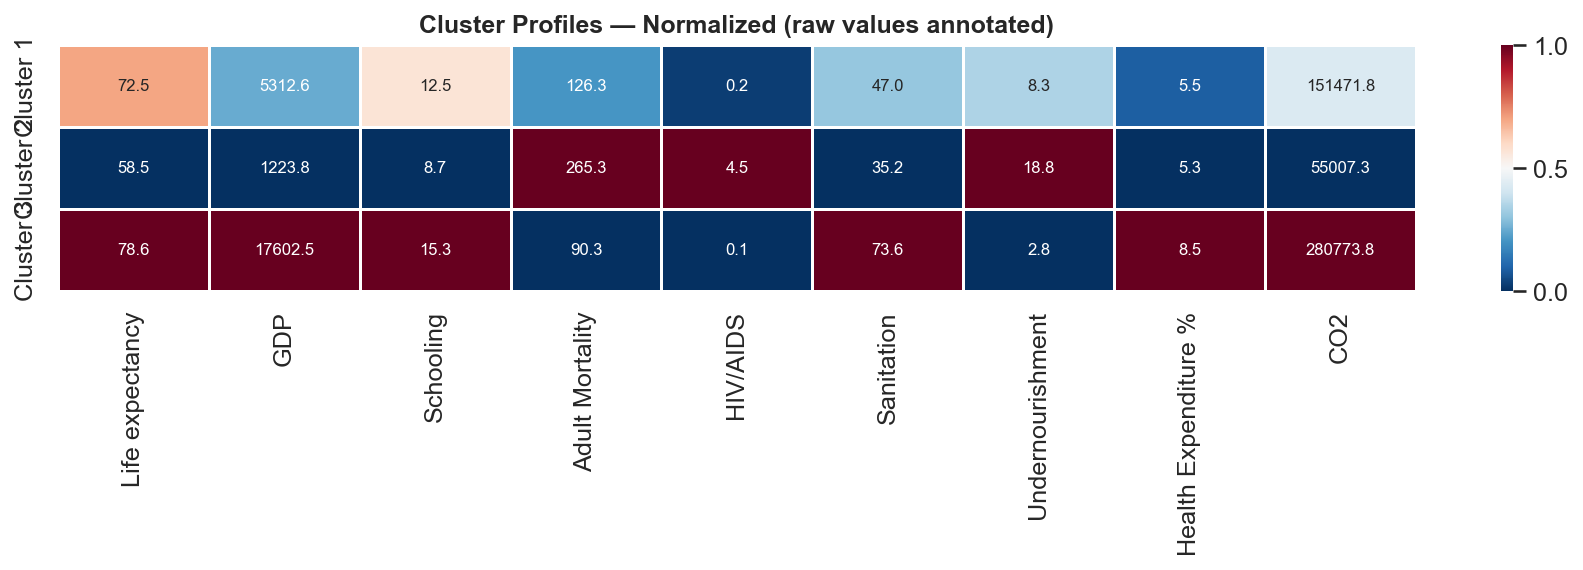

Figure saved.


In [28]:
PROFILE_VARS = ['Life expectancy', 'GDP', 'Schooling', 'Adult Mortality',
                'HIV/AIDS', 'Sanitation', 'Undernourishment',
                'Health Expenditure %', 'CO2']
PROFILE_VARS = [v for v in PROFILE_VARS if v in df.columns]

profile = df.groupby('Cluster')[PROFILE_VARS].mean().round(2)
profile.index = [f'Cluster {i}' for i in profile.index]

print("Cluster Profiles (Mean Values):")
display(profile)
profile.to_csv(os.path.join(TABLE_DIR, "cluster_profiles.csv"))

# Heatmap
from sklearn.preprocessing import MinMaxScaler
profile_norm = profile.copy()
mm = MinMaxScaler()
profile_norm[PROFILE_VARS] = mm.fit_transform(profile[PROFILE_VARS])

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(profile_norm, annot=profile.values, fmt='.1f',
            cmap='RdBu_r', center=0.5, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title("Cluster Profiles — Normalized (raw values annotated)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig10_cluster_profiles.png"), dpi=150)
plt.show()
print("Figure saved.")


---
## Step 21 — Cluster Boxplots (Key Variables)


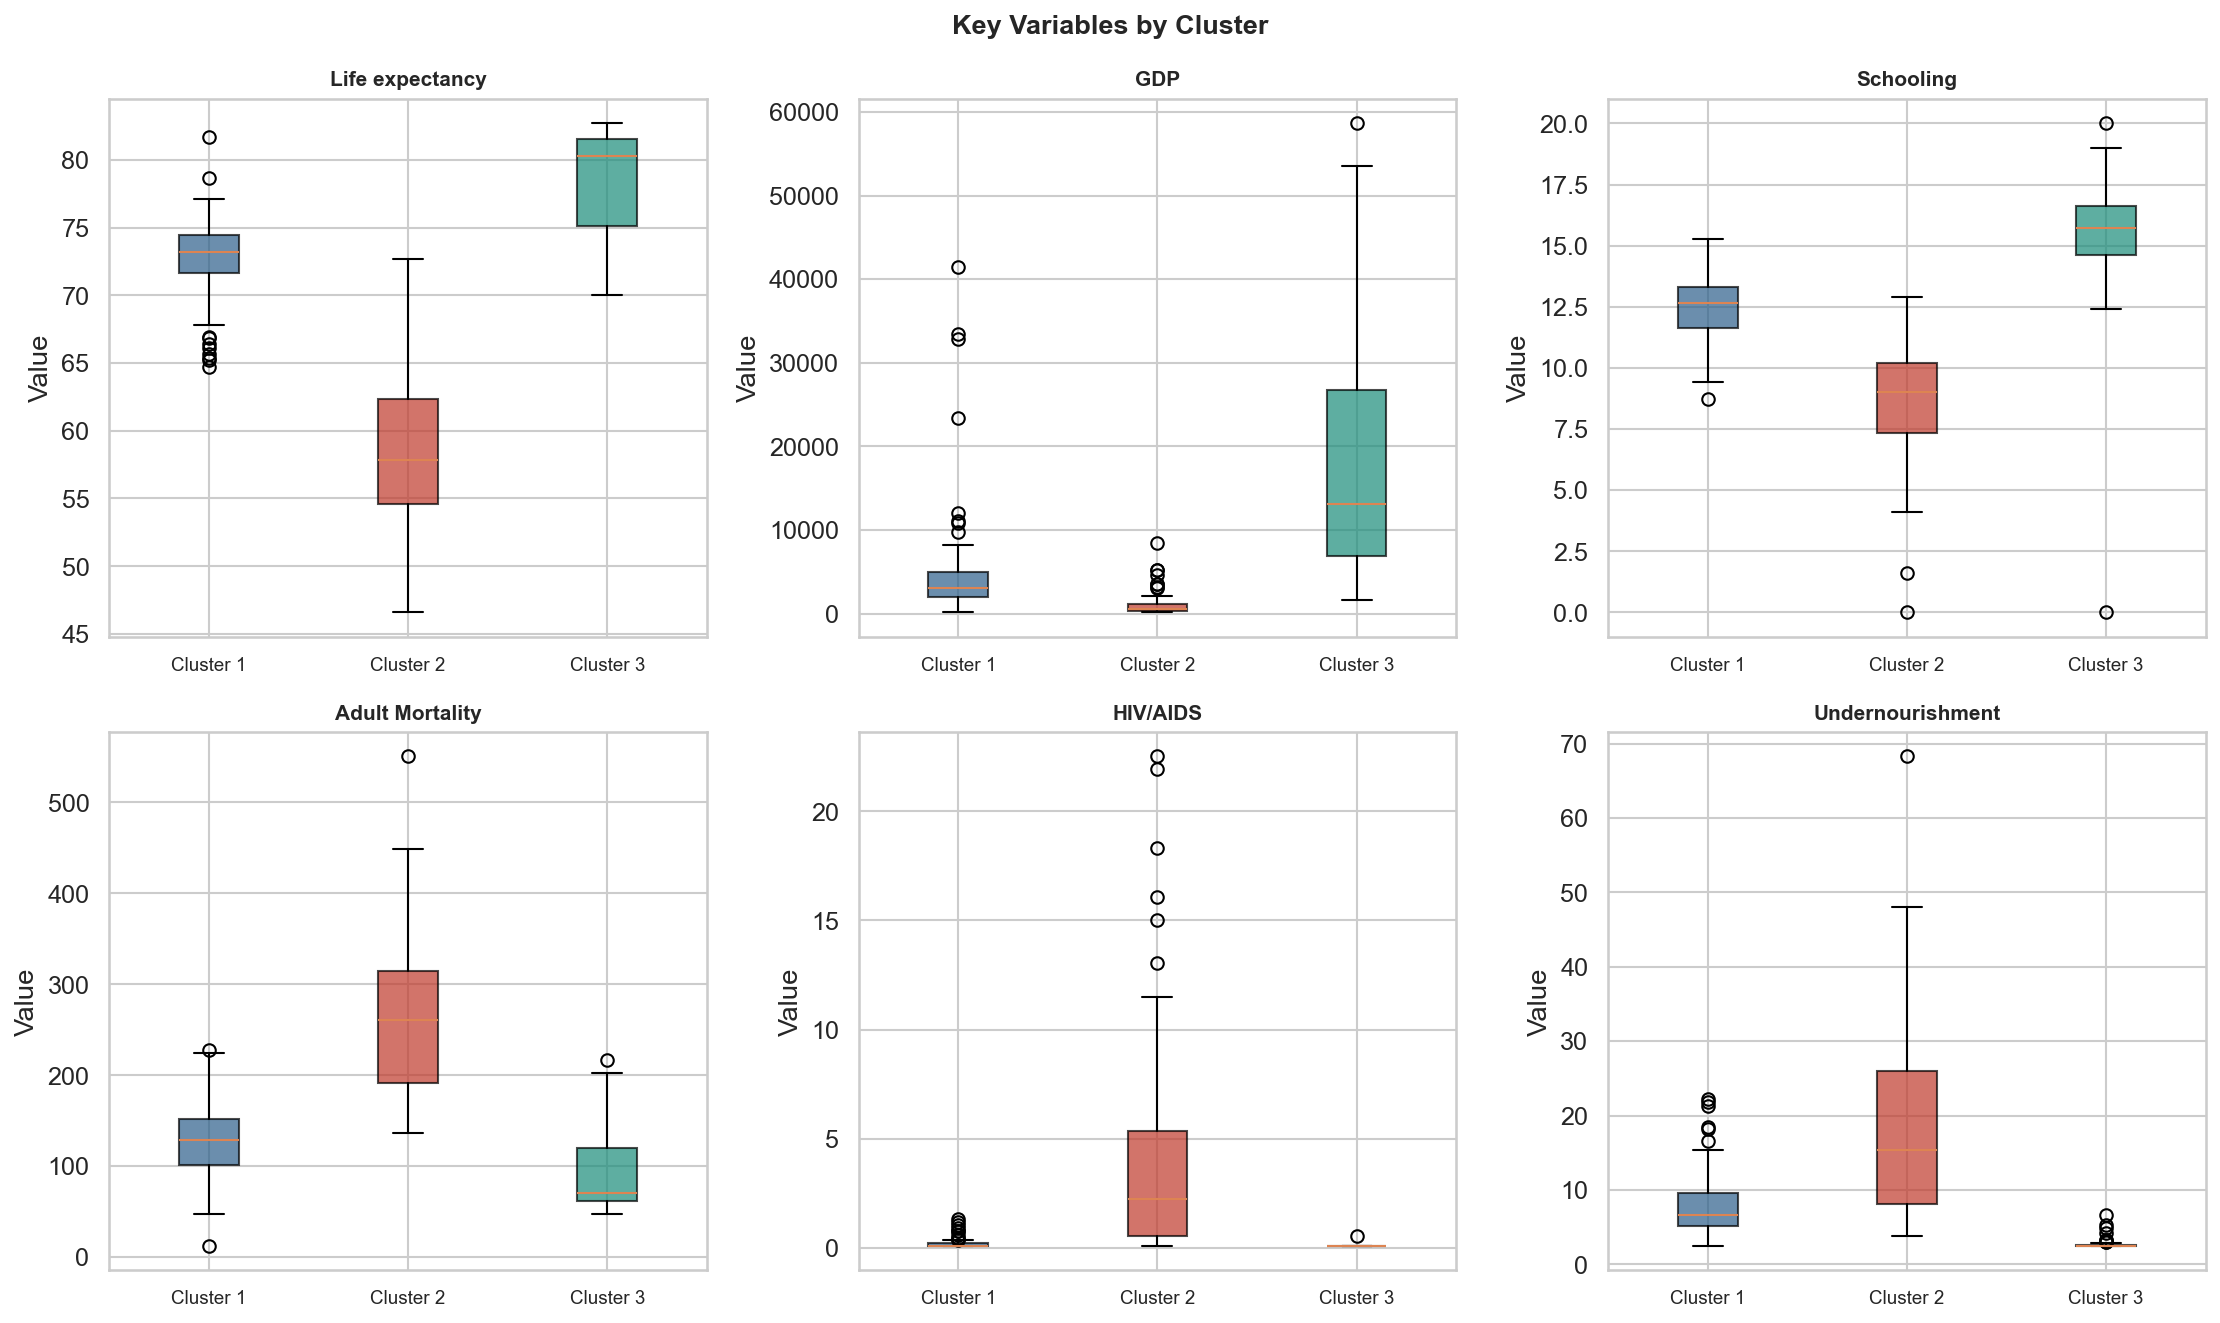

Figure saved.


In [29]:
box_vars = ['Life expectancy', 'GDP', 'Schooling',
            'Adult Mortality', 'HIV/AIDS', 'Undernourishment']
box_vars = [v for v in box_vars if v in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
colors = ['#2C5F8A', '#C0392B', '#1A8C7A', '#E67E22', '#6C3483']

for i, var in enumerate(box_vars):
    data_by_cluster = [df[df['Cluster']==c][var].dropna()
                       for c in sorted(df['Cluster'].unique())]
    bp = axes[i].boxplot(data_by_cluster, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    axes[i].set_xticklabels([f'Cluster {c}' for c in sorted(df['Cluster'].unique())],
                             fontsize=9)
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].set_ylabel("Value")

plt.suptitle("Key Variables by Cluster", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig11_cluster_boxplots.png"), dpi=150)
plt.show()
print("Figure saved.")


---
## Step 22 — PCA Biplot


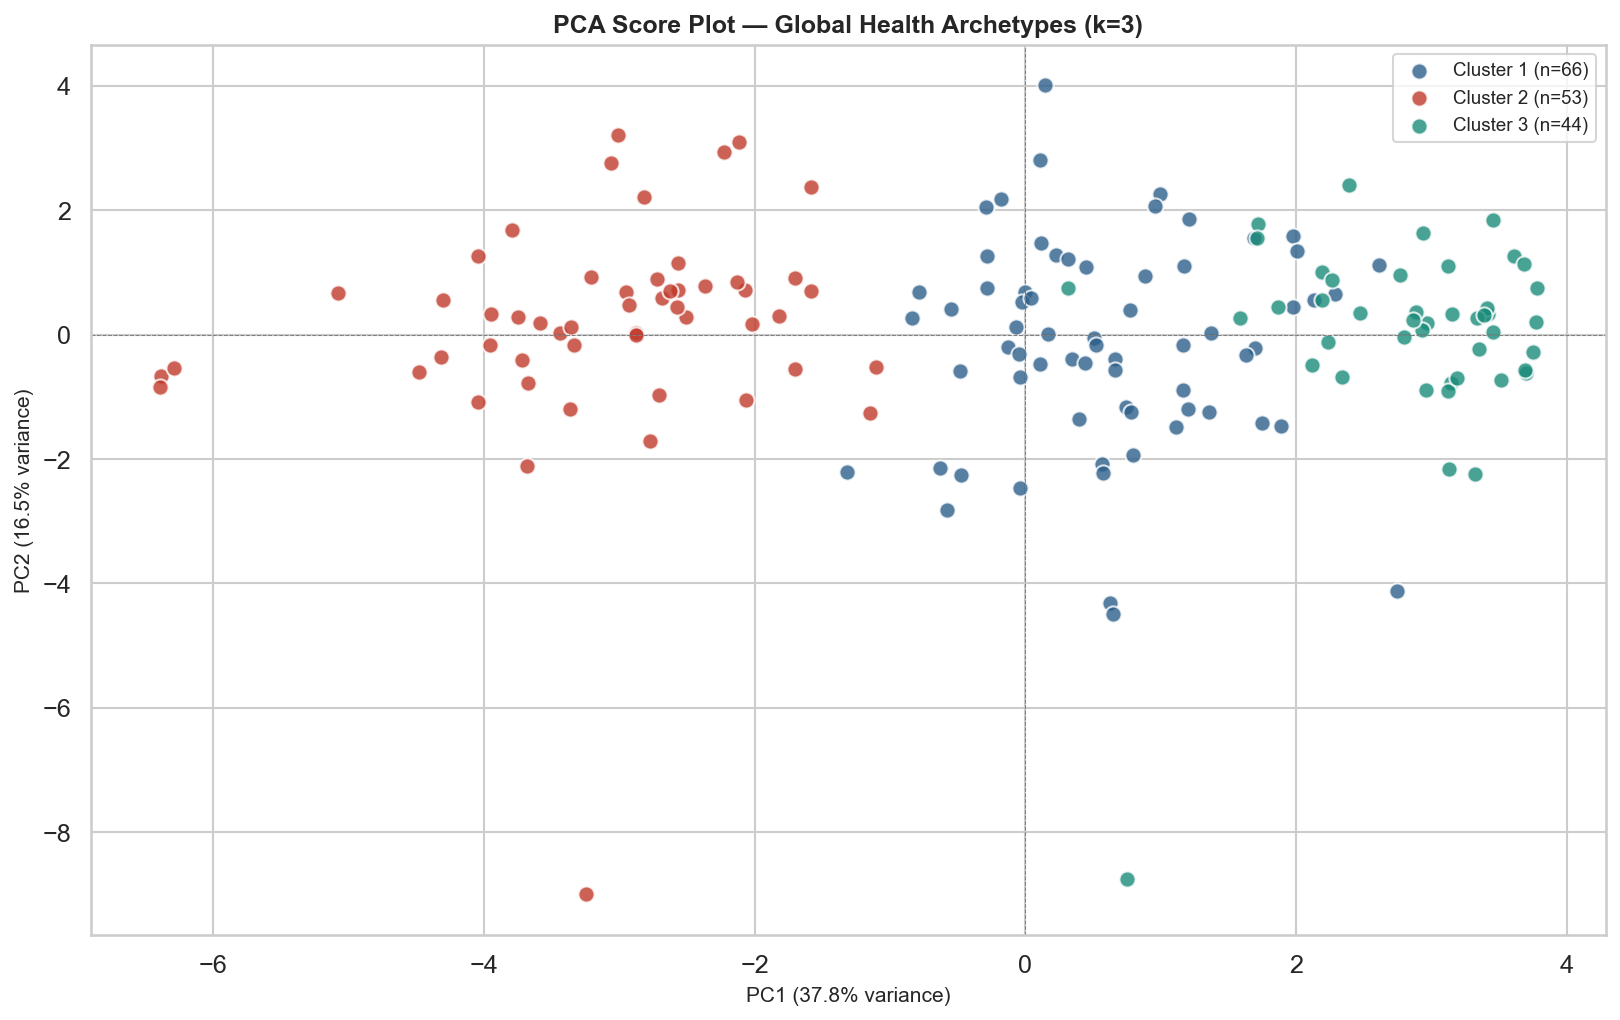

Figure saved.


In [30]:
fig, ax = plt.subplots(figsize=(11, 7))
colors  = ['#2C5F8A', '#C0392B', '#1A8C7A', '#E67E22', '#6C3483']

for c in sorted(df['Cluster'].unique()):
    idx = df[df['Cluster']==c].index
    n   = len(idx)
    ax.scatter(X_pca_scores[idx, 0], X_pca_scores[idx, 1],
               color=colors[c-1], s=60, alpha=0.8,
               edgecolors='white', label=f'Cluster {c} (n={n})')
    # Annotate small clusters
    if n <= 5:
        for j in idx:
            ax.annotate(df.loc[j, 'Country'],
                       (X_pca_scores[j, 0], X_pca_scores[j, 1]),
                       fontsize=8, fontweight='bold',
                       xytext=(5, 5), textcoords='offset points')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f"PC1 ({ev_ratio[0]*100:.1f}% variance)", fontsize=10)
ax.set_ylabel(f"PC2 ({ev_ratio[1]*100:.1f}% variance)", fontsize=10)
ax.set_title("PCA Score Plot — Global Health Archetypes (k=3)",
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig12_pca_score_plot.png"), dpi=150)
plt.show()
print("Figure saved.")


---
## Step 23 — External Cluster Validation


In [31]:
# Chi-square vs Income Group
ct_income = pd.crosstab(df['Cluster'], df['IncomeGroup'])
chi2_inc, p_inc, dof_inc, _ = chi2_contingency(ct_income)
print("=== Chi-square: Cluster vs Income Group ===")
display(ct_income)
print(f"chi2 = {chi2_inc:.2f}, df = {dof_inc}, p = {p_inc:.6f}")

# Chi-square vs Region
ct_region = pd.crosstab(df['Cluster'], df['Region'])
chi2_reg, p_reg, dof_reg, _ = chi2_contingency(ct_region)
print("\n=== Chi-square: Cluster vs Region ===")
display(ct_region)
print(f"chi2 = {chi2_reg:.2f}, df = {dof_reg}, p = {p_reg:.6f}")

# Adjusted Rand Index
income_enc = pd.Categorical(df['IncomeGroup']).codes
region_enc = pd.Categorical(df['Region']).codes
ari_income = adjusted_rand_score(df['Cluster'], income_enc)
ari_region = adjusted_rand_score(df['Cluster'], region_enc)

print(f"\n=== Adjusted Rand Index ===")
print(f"ARI vs Income Group : {ari_income:.3f}")
print(f"ARI vs Region       : {ari_region:.3f}")

# Save
validation_df = pd.DataFrame({
    'Test'     : ['Chi-square vs Income', 'Chi-square vs Region',
                  'ARI vs Income',        'ARI vs Region'],
    'Statistic': [chi2_inc, chi2_reg, ari_income, ari_region],
    'p-value'  : [p_inc, p_reg, '-', '-']
})
validation_df.to_csv(os.path.join(TABLE_DIR, "external_validation.csv"), index=False)


=== Chi-square: Cluster vs Income Group ===


IncomeGroup,High income,Low income,Lower middle income,Upper middle income
Cluster,,,,
1,15,0,19,32
2,0,23,23,7
3,36,0,1,7


chi2 = 133.63, df = 6, p = 0.000000

=== Chi-square: Cluster vs Region ===


Region,East Asia & Pacific,Europe & Central Asia,Latin America & Caribbean,Middle East & North Africa,North America,South Asia,Sub-Saharan Africa
Cluster,,,,,,,
1,14,12,22,12,0,3,3
2,6,0,1,2,0,5,39
3,4,31,5,2,2,0,0


chi2 = 157.05, df = 12, p = 0.000000

=== Adjusted Rand Index ===
ARI vs Income Group : 0.278
ARI vs Region       : 0.318


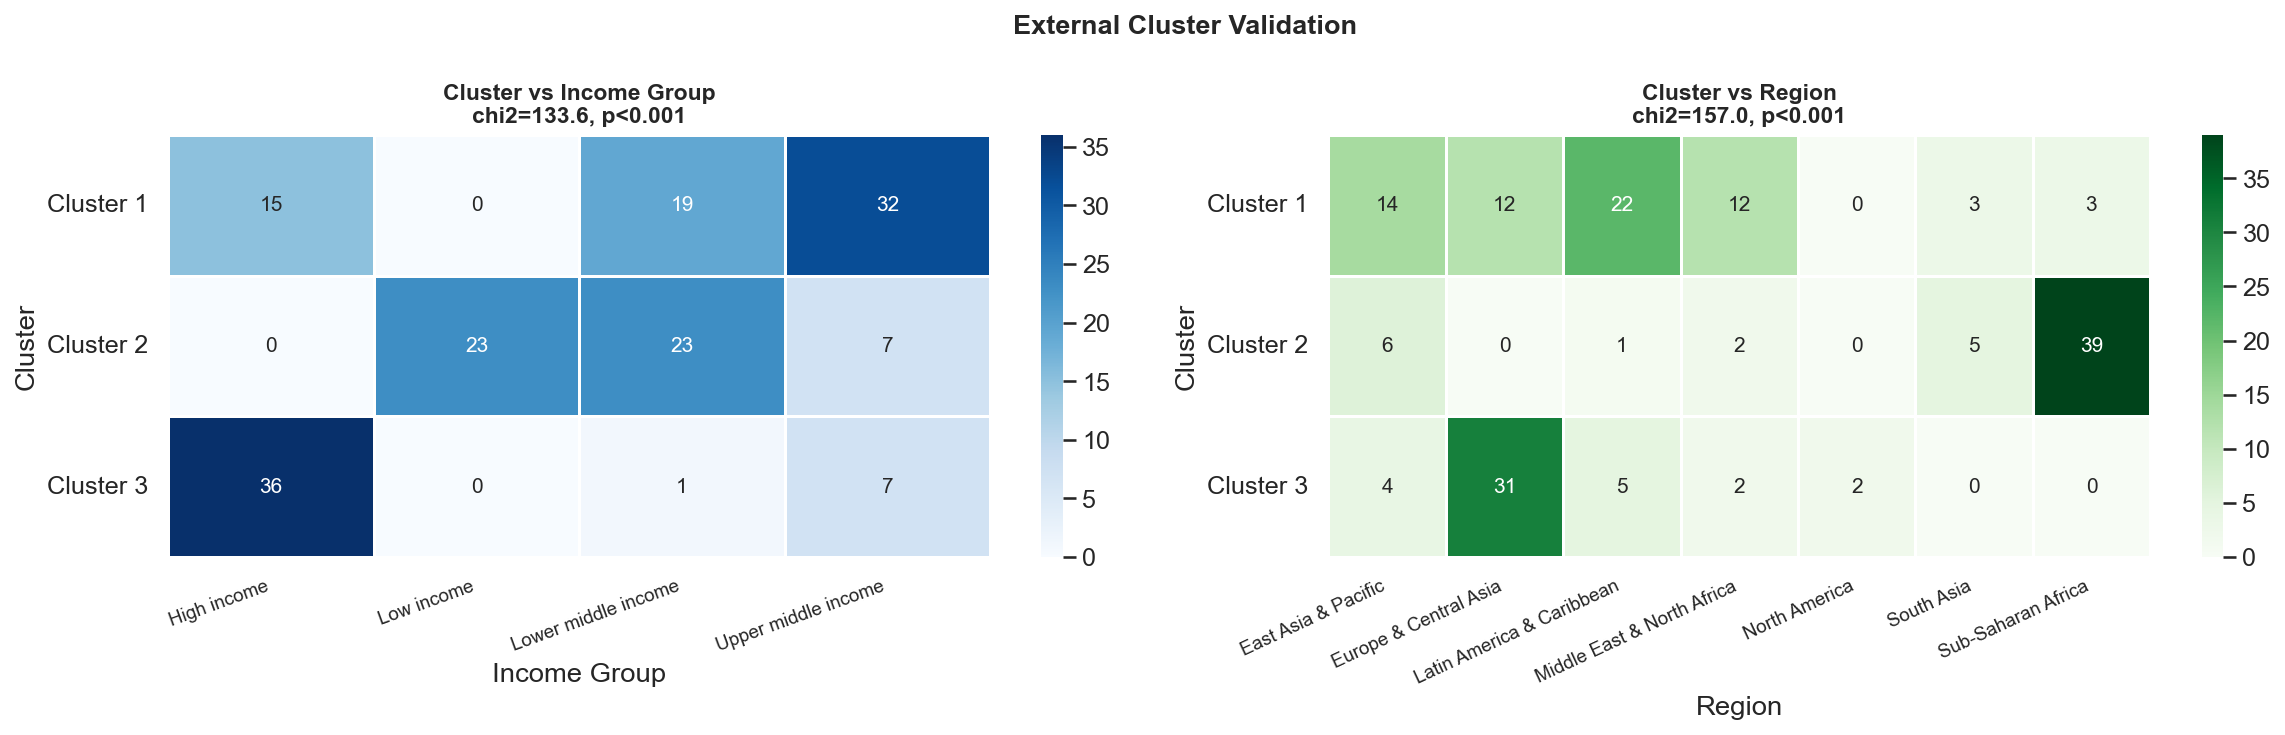

Figure saved.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(ct_income, annot=True, fmt='d', cmap='Blues',
            ax=axes[0], linewidths=0.5, annot_kws={'size': 10})
axes[0].set_title(f"Cluster vs Income Group\nchi2={chi2_inc:.1f}, p<0.001",
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel("Income Group")
axes[0].set_ylabel("Cluster")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right', fontsize=9)
axes[0].set_yticklabels([f'Cluster {c}' for c in ct_income.index], rotation=0)

sns.heatmap(ct_region, annot=True, fmt='d', cmap='Greens',
            ax=axes[1], linewidths=0.5, annot_kws={'size': 10})
axes[1].set_title(f"Cluster vs Region\nchi2={chi2_reg:.1f}, p<0.001",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Cluster")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right', fontsize=9)
axes[1].set_yticklabels([f'Cluster {c}' for c in ct_region.index], rotation=0)

plt.suptitle("External Cluster Validation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "fig13_external_validation.png"), dpi=150)
plt.show()
print("Figure saved.")


---
## Step 24 — Export Final Dataset


In [33]:
export_cols = ['Country', 'Region', 'IncomeGroup', 'Cluster'] + PROFILE_VARS
df_export = df[export_cols].copy()
df_export.to_csv(os.path.join(TABLE_DIR, "final_clustered_dataset.csv"), index=False)

print("All outputs saved.")
print(f"  Images : {IMAGE_DIR}/")
print(f"  Tables : {TABLE_DIR}/")
print(f"  Final dataset shape: {df_export.shape}")
print()
print("=" * 50)
print("ANALYSIS SUMMARY")
print("=" * 50)
print(f"Countries analysed      : {len(df)}")
print(f"Features used           : {len(available)}")
print(f"Regression — Full model R²      : {model_full.rsquared:.3f}  (explanatory coverage)")
print(f"Regression — Refined model R²   : {model_refined.rsquared:.3f}  (stable coefficient interpretation)")
print(f"Regression — Robustness R²      : {model_no_am.rsquared:.3f}  (without Adult Mortality)")
print(f"Regression F-stat p (full)      : {model_full.f_pvalue:.2e}")
print(f"Regression F-stat p (refined)   : {model_refined.f_pvalue:.2e}")
print(f"PCA components          : {n_comp} ({cum_var[n_comp-1]:.1%} variance)")
print(f"Selected clusters (k)    : {best_k}")
selected_silhouette = silhouettes[list(K_RANGE).index(best_k)]
print(f"Silhouette Score (k={best_k})    : {selected_silhouette:.3f}")
print(f"Note: k=2 had higher silhouette ({max(silhouettes):.3f}) but k={best_k} was selected for interpretability")
print(f"ARI vs Income Group     : {ari_income:.3f}")
print(f"ARI vs Region           : {ari_region:.3f}")


All outputs saved.
  Images : report_images/
  Tables : report_tables/
  Final dataset shape: (163, 13)

ANALYSIS SUMMARY
Countries analysed      : 163
Features used           : 18
Regression — Full model R²      : 0.927  (explanatory coverage)
Regression — Refined model R²   : 0.800  (stable coefficient interpretation)
Regression — Robustness R²      : 0.883  (without Adult Mortality)
Regression F-stat p (full)      : 3.15e-82
Regression F-stat p (refined)   : 5.10e-53
PCA components          : 6 (85.1% variance)
Selected clusters (k)    : 3
Silhouette Score (k=3)    : 0.258
Note: k=2 had higher silhouette (0.343) but k=3 was selected for interpretability
ARI vs Income Group     : 0.278
ARI vs Region           : 0.318
